# Lab 2: Auditing a Quantum Advantage Claim — Student Worksheet

> **Core claim under audit:** "Because this problem is naturally written as an Ising Hamiltonian and a quantum circuit can sample candidate low-energy configurations, a meaningful quantum advantage is likely."

This worksheet version keeps the full notebook structure but leaves the Case B investigation for you to complete with code, plots, and short written judgments.


## 0. Objective and How To Use This Notebook

In this notebook you will:
- work through one guided case study first,
- analyze a stronger case more independently afterward,
- revise an initial verdict as new evidence arrives,
- write short evidence-backed conclusions directly next to the code and figures.

How to use it:
1. Run the setup section once.
2. Treat Case A as a worked example of the full checklist.
3. In Case B, use the `TODO` comments in the code cells as your worksheet instructions.
4. Fill in the blank tables and prompts with your own evidence-based reasoning.
5. Treat every verdict as conditional on the assumptions stated nearby.

The goal is not to derive a new quantum algorithm. The goal is to audit whether an advantage claim survives disciplined end-to-end scrutiny.


### Before You Start: Make a Provisional Call

> **Claim under audit:** because the problem is naturally written as an Ising Hamiltonian and a quantum circuit can sample candidate low-energy configurations, a meaningful quantum advantage is likely.

**Pause before reading further.** Write a first impression:
- My initial verdict: `plausible / unclear / weak`
- The checklist step I expect to matter most:
- One kind of evidence that would change my mind:


### Quick Ising Refresher

In this lab, each spin can point in one of two directions,

$$
s_i \in \{-1, +1\}.
$$

A simple Ising Hamiltonian collects two kinds of energetic preferences,

$$
H(s) = \sum_i h_i s_i + \sum_{i<j} J_{ij} s_i s_j.
$$

Here:
- $h_i s_i$ is a **local-field term**: it biases spin $i$ toward one orientation.
- $J_{ij} s_i s_j$ is a **coupling term** between spins $i$ and $j$.

If $J_{ij} < 0$, the energy is lowered when the two spins align. If $J_{ij} > 0$, the energy is lowered when they anti-align.

Low-energy states are the spin assignments that satisfy as many of these preferences as possible. When different terms compete, the system is **frustrated**: not all preferences can be satisfied at once, so the low-energy states are compromises.

That is why Ising language is attractive here: it gives a compact physics description of the problem. But writing a problem as an Ising Hamiltonian is only the start of the audit, not the end of it.


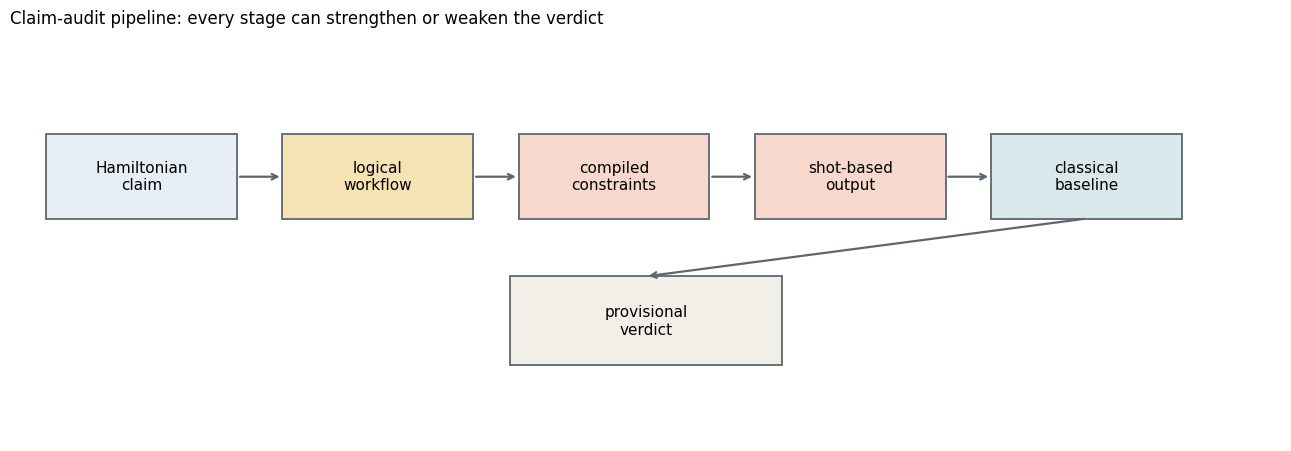

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

edge_color = '#5b6770'
fig, ax = plt.subplots(figsize=(12.8, 4.4), constrained_layout=True)
ax.set_xlim(0, 14)
ax.set_ylim(0, 4.6)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

boxes = [
    (0.4, 2.5, 2.1, 0.95, 'Hamiltonian\nclaim', '#e7eef6'),
    (3.0, 2.5, 2.1, 0.95, 'logical\nworkflow', '#f6e3b3'),
    (5.6, 2.5, 2.1, 0.95, 'compiled\nconstraints', '#f6d9cc'),
    (8.2, 2.5, 2.1, 0.95, 'shot-based\noutput', '#f6d9cc'),
    (10.8, 2.5, 2.1, 0.95, 'classical\nbaseline', '#d9e8ea'),
    (5.5, 0.85, 3.0, 1.0, 'provisional\nverdict', '#f2eee8'),
]

for x, y, w, h, label, color in boxes:
    rect = Rectangle((x, y), w, h, facecolor=color, edgecolor=edge_color, linewidth=1.3)
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, label, ha='center', va='center', fontsize=11)

for x0, x1 in [(2.5, 3.0), (5.1, 5.6), (7.7, 8.2), (10.3, 10.8)]:
    ax.annotate('', xy=(x1, 2.97), xytext=(x0, 2.97), arrowprops={'arrowstyle': '->', 'linewidth': 1.6, 'color': edge_color})
ax.annotate('', xy=(7.0, 1.85), xytext=(11.85, 2.5), arrowprops={'arrowstyle': '->', 'linewidth': 1.6, 'color': edge_color})
ax.set_title('Claim-audit pipeline: every stage can strengthen or weaken the verdict', loc='left')
plt.show()


This notebook works like a live investigation. You should expect your first verdict to move. Some sections will make the claim look stronger; others will expose hidden costs or weak comparisons. The point is not to be impressed early. The point is to update your judgment carefully.


## 1. The Checklist for Judging Quantum Advantage

**What has to be true before an Ising-style quantum workflow becomes a credible end-to-end advantage claim?**

We will reuse the same six questions throughout the lab.

| Step | Question | What must be checked |
|---|---|---|
| 1 | What problem structure is being exploited? | Symmetry, locality, frustration, sparsity, constraints, or other structure that could plausibly matter computationally. |
| 2 | What does the problem-class language really imply here? | Whether labels such as `NP-hard`, `optimization`, or `Ising` actually support an advantage claim or only describe the task class. |
| 3 | How is the input loaded and how is the output extracted? | What classical information must be encoded, what samples come back, and how much post-processing is still needed. |
| 4 | What hardware, routing, depth, and shot costs are being paid? | Logical interactions, device topology, routing overhead, compilation depth, repeated measurements, and budget limits. |
| 5 | Is the classical baseline strong, fair, and up to date? | Whether the comparison is against a serious classical method instead of a weak straw-man baseline. |
| 6 | After all of that, how strong is the end-to-end case for advantage? | Whether the full pipeline still leaves a believable practical gain rather than only an appealing abstract story. |

> **Takeaway:** Writing a problem as an Ising Hamiltonian is only the start. A meaningful advantage claim must also survive input/output, compilation, hardware, shot, and baseline checks.

## 2. Setup and Helper Utilities

The setup cell below follows the local repository convention: use the shared plotting/style utilities, keep the scientific stack minimal, and stay compatible with the existing `.venv`.

The custom helpers in this notebook are intentionally small and transparent. They are teaching tools, not a hidden framework.

In [4]:
!pip install pandas
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'utilities' / 'complexity_utils.py').exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from collections import Counter, deque

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown

from utilities.complexity_utils import (
    COLORS,
    display_wrapped,
    instructor_prompt,
    lecture_figure,
    markdown_box,
    setup_lecture_style,
)

setup_lecture_style()
LAB_SEED = 7
rng = np.random.default_rng(LAB_SEED)
np.set_printoptions(precision=3, suppress=True)
pd.options.display.float_format = lambda value: f'{value:,.3g}'


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


The helper cells below define only the functions that are clearly reusable later in the lab:
- Ising-state enumeration and energy evaluation
- interaction-graph construction and plotting
- simple device-topology models and routing-distance proxies
- greedy layering of non-conflicting logical interactions
- a small classical local-search baseline
- a **toy** shot-based sampling proxy for output-stability reflection

All couplings use **0-based Python indices** in the helper code. The toy sampler is explicitly **not** a faithful simulation of QAOA, annealing, or hardware noise.


The helper section is now split into small notebook-sized tools. Each helper gets:
- a short note about what it takes as input,
- what it returns,
- and why it matters later in the audit.

All couplings use **0-based Python indices** in the helper code. The shot-based sampler remains an explicitly labeled **toy proxy**, not a faithful simulation of QAOA, annealing, or hardware noise.


### Helper: `canonical_edge`

**Purpose:** standardize an undirected interaction edge.

**Inputs:** two node labels `u` and `v`.

**Output:** the same edge written in sorted order `(min(u, v), max(u, v))`.

We use this to avoid treating `(1, 3)` and `(3, 1)` as different couplings.


In [5]:
def canonical_edge(u, v):
    """Return an undirected edge in a stable order."""
    # The helper expects a genuine interaction between two different nodes.
    if u == v:
        raise ValueError('Self-loops are not supported in this notebook.')

    # Store the edge in sorted order so later lookups stay consistent.
    return (u, v) if u < v else (v, u)


### Helper: `spins_to_bitstring`

**Purpose:** convert a spin configuration into a compact display string.

**Input:** one spin array with entries in `{+1, -1}`.

**Output:** a bitstring where `+1 -> 0` and `-1 -> 1`.

This is only a display convention, but it makes tables and sampling outputs easier to read.


In [6]:
def spins_to_bitstring(spins):
    """Map +1 -> 0 and -1 -> 1 for compact display."""
    # Convert to a NumPy array so the helper accepts lists, tuples, and arrays.
    spin_array = np.asarray(spins, dtype=int)

    # The mapping is a display choice used consistently throughout the notebook.
    return ''.join('0' if value == 1 else '1' for value in spin_array)


### Helper: `all_spin_configurations`

**Purpose:** enumerate the full Ising state space.

**Input:** `num_spins`, the number of spins in the problem.

**Output:** an array of shape `(2^n, n)` containing every spin assignment in `{+1, -1}^n`.

This helper is what allows the small lab instances to be solved exactly.


In [7]:
def all_spin_configurations(num_spins):
    """Enumerate all spin assignments in {-1, +1}^n."""
    if num_spins < 1:
        raise ValueError('num_spins must be positive.')

    # First enumerate binary patterns in {0, 1}^n.
    bit_patterns = np.array(list(np.ndindex(*(2,) * num_spins)), dtype=int)

    # Then remap 0 -> +1 and 1 -> -1 to obtain Ising spins.
    return 1 - 2 * bit_patterns


### Helper: `ising_energy`

**Purpose:** evaluate the Ising Hamiltonian on one configuration or a batch of configurations.

**Inputs:**
- `spins`: one spin vector or a stack of spin vectors,
- `h`: the local-field array,
- `couplings`: a dictionary mapping edges to weights.

**Output:** one energy or a NumPy array of energies.

This is the core evaluator used by enumeration, local search, and the toy sampler.


In [8]:
def ising_energy(spins, h, couplings):
    """Compute Ising energies for one configuration or a batch of configurations."""
    spin_array = np.asarray(spins, dtype=int)
    single_configuration = spin_array.ndim == 1

    # Promote one configuration to shape (1, n) so one code path handles both cases.
    if single_configuration:
        spin_array = spin_array[None, :]

    h = np.asarray(h, dtype=float)
    if spin_array.shape[1] != len(h):
        raise ValueError('Spin length and field length must agree.')

    # Start with the local-field contribution sum_i h_i s_i.
    energies = spin_array @ h

    # Add the pairwise interaction contribution sum_{i,j} J_ij s_i s_j.
    for (u, v), weight in couplings.items():
        i, j = canonical_edge(u, v)
        energies += float(weight) * spin_array[:, i] * spin_array[:, j]

    # Match the input style: scalar out for one state, array out for many states.
    return float(energies[0]) if single_configuration else energies


### Helper: `enumerate_ising_energies`

**Purpose:** build a full energy table for a small Ising instance.

**Inputs:** the field vector `h` and the coupling dictionary `couplings`.

**Output:** a pandas table containing the bitstring, spin tuple, and energy for every state.

This turns exact enumeration into a reusable one-line operation for both Case A and Case B.


In [9]:
def enumerate_ising_energies(h, couplings):
    """Enumerate every spin configuration and its energy."""
    # Generate the entire state space for the given number of spins.
    states = all_spin_configurations(len(h))
    energies = ising_energy(states, h, couplings)

    # Keep both a display bitstring and the raw spin tuple for later analysis.
    energy_table = pd.DataFrame(
        {
            'bitstring': [spins_to_bitstring(state) for state in states],
            'spins': [tuple(int(value) for value in state) for state in states],
            'energy': energies,
        }
    )

    # Sort by energy first so low-energy structure is easy to inspect.
    return energy_table.sort_values(['energy', 'bitstring'], ignore_index=True)


### Helper: `build_interaction_graph`

**Purpose:** convert the coupling dictionary into an undirected adjacency map.

**Inputs:**
- `num_spins`,
- `couplings` as edge-weight pairs.

**Output:** a dictionary of dictionaries describing the weighted interaction graph.

This is the graph-language bridge between the Hamiltonian and later structure or routing discussions.


In [10]:
def build_interaction_graph(num_spins, couplings):
    """Store weighted Ising couplings as an undirected adjacency map."""
    # Start every spin with an empty neighbor list.
    graph = {node: {} for node in range(num_spins)}

    for (u, v), weight in couplings.items():
        i, j = canonical_edge(u, v)
        if not (0 <= i < num_spins and 0 <= j < num_spins):
            raise ValueError('Coupling edge is outside the declared spin range.')

        # Record the same weighted edge in both directions.
        graph[i][j] = float(weight)
        graph[j][i] = float(weight)

    return graph


### Helper: `circular_layout`

**Purpose:** place graph nodes on a stable circle for small pedagogical plots.

**Inputs:** `num_nodes` and an optional `radius`.

**Output:** a dictionary mapping each node label to an `(x, y)` position.

The point is not graph-drawing optimality. The point is consistent visual comparison across sections.


In [11]:
def circular_layout(num_nodes, radius=1.0):
    """Place nodes on a circle for stable small-graph plots."""
    # Space the nodes evenly around a full turn.
    angles = np.linspace(np.pi / 2, np.pi / 2 + 2 * np.pi, num_nodes, endpoint=False)

    # Return a predictable position map keyed by node index.
    return {node: (radius * np.cos(angle), radius * np.sin(angle)) for node, angle in enumerate(angles)}


### Helper: `plot_interaction_graph`

**Purpose:** draw the Ising interaction graph with coupling signs and optional local fields.

**Inputs:**
- `num_spins`,
- `couplings`,
- optional field vector `h`,
- optional node positions,
- optional plot title.

**Output:** the Matplotlib figure and axis.

This is the main visual bridge from Hamiltonian notation to problem-structure inspection.


In [12]:
def plot_interaction_graph(num_spins, couplings, h=None, positions=None, *, title='Interaction graph'):
    """Plot a small weighted interaction graph with field labels on the nodes."""
    if positions is None:
        positions = circular_layout(num_spins)

    fig, ax = lecture_figure(kind='square')

    # Draw each coupling once, with color encoding the sign of J.
    for (u, v), weight in sorted({canonical_edge(*edge): value for edge, value in couplings.items()}.items()):
        x0, y0 = positions[u]
        x1, y1 = positions[v]
        color = COLORS['teal'] if weight < 0 else COLORS['rust']
        linewidth = 1.6 + 0.8 * abs(weight)
        ax.plot([x0, x1], [y0, y1], color=color, linewidth=linewidth, zorder=1)
        ax.text(
            (x0 + x1) / 2,
            (y0 + y1) / 2,
            f'{weight:+.2f}',
            fontsize=10,
            color=color,
            ha='center',
            va='center',
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.9, 'pad': 0.6},
            zorder=2,
        )

    h = None if h is None else np.asarray(h, dtype=float)
    for node, (x, y) in positions.items():
        # Draw a simple labeled node; include h_i when a field vector is provided.
        circle = plt.Circle((x, y), 0.14, facecolor='white', edgecolor=COLORS['gray'], linewidth=1.3, zorder=3)
        ax.add_patch(circle)
        field_text = '' if h is None else f'\nh={h[node]:+.2f}'
        ax.text(x, y, f's{node + 1}{field_text}', ha='center', va='center', fontsize=10, zorder=4)

    xs = [x for x, _ in positions.values()]
    ys = [y for _, y in positions.values()]
    ax.set_xlim(min(xs) - 0.45, max(xs) + 0.45)
    ax.set_ylim(min(ys) - 0.45, max(ys) + 0.45)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, loc='left')
    return fig, ax


### Helper: `build_device_graph`

**Purpose:** create a simple hardware-connectivity graph.

**Inputs:**
- `num_qubits`,
- `topology`, chosen from `line`, `ring`, or `all_to_all`.

**Output:** an adjacency list for the chosen device graph.

This helper keeps the later transpilation discussion transparent and dependency-light.


In [13]:
def build_device_graph(num_qubits, topology):
    """Construct a small undirected device graph for routing proxies."""
    if num_qubits < 1:
        raise ValueError('num_qubits must be positive.')

    graph = {node: set() for node in range(num_qubits)}

    # Choose a simple connectivity pattern for the routing proxy.
    if topology == 'line':
        edges = [(i, i + 1) for i in range(num_qubits - 1)]
    elif topology == 'ring':
        edges = [(i, i + 1) for i in range(num_qubits - 1)]
        if num_qubits > 2:
            edges.append((num_qubits - 1, 0))
    elif topology == 'all_to_all':
        edges = [(i, j) for i in range(num_qubits) for j in range(i + 1, num_qubits)]
    else:
        raise ValueError("Topology must be 'line', 'ring', or 'all_to_all'.")

    # Turn the edge list into an undirected adjacency map.
    for u, v in edges:
        graph[u].add(v)
        graph[v].add(u)

    return {node: sorted(neighbors) for node, neighbors in graph.items()}


### Helper: `shortest_path_distance`

**Purpose:** measure how far apart two qubits are on a device graph.

**Inputs:** the graph, a source node, and a target node.

**Output:** the length of one shortest path between those nodes.

This is the routing primitive behind the notebook's compiled-cost proxy.


In [14]:
def shortest_path_distance(graph, source, target):
    """Compute one shortest-path distance on an unweighted graph."""
    if source == target:
        return 0

    # Breadth-first search is enough because every edge has equal weight here.
    queue = deque([(source, 0)])
    visited = {source}

    while queue:
        node, distance = queue.popleft()
        for neighbor in graph[node]:
            if neighbor == target:
                return distance + 1
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, distance + 1))

    raise ValueError('Graph is disconnected for the requested nodes.')


### Helper: `rough_compiled_edge_cost`

**Purpose:** assign a simple compiled two-qubit cost to one logical interaction.

**Inputs:** one logical edge and one device graph.

**Output:** the proxy cost `2d - 1`, where `d` is the shortest-path distance.

This is a toy compilation rule, but it makes the routing penalty explicit and easy to audit.


In [15]:
def rough_compiled_edge_cost(edge, device_graph):
    """Proxy compiled two-qubit cost: one adjacent interaction costs 1, distance d costs 2d - 1."""
    # Normalize the logical edge before looking it up.
    u, v = canonical_edge(*edge)
    distance = shortest_path_distance(device_graph, u, v)

    # Distance 1 gives cost 1; longer routes grow linearly under this proxy.
    return 2 * distance - 1


### Helper: `greedy_edge_layers`

**Purpose:** pack non-conflicting logical interactions into parallel layers.

**Input:** a list of edges.

**Output:** a list of layers, where no two edges in the same layer share a node.

This gives a logical-depth estimate before any hardware compilation is considered.


In [16]:
def greedy_edge_layers(edges):
    """Group non-conflicting edges into parallel logical layers."""
    layers = []

    # Scan the edges in a stable order and place each edge in the earliest valid layer.
    for edge in sorted({canonical_edge(*edge) for edge in edges}):
        u, v = edge
        placed = False
        for layer in layers:
            used_nodes = {node for pair in layer for node in pair}
            if u not in used_nodes and v not in used_nodes:
                layer.append(edge)
                placed = True
                break

        # If no existing layer can host the edge, start a new one.
        if not placed:
            layers.append([edge])

    return layers


### Helper: `greedy_single_flip_descent`

**Purpose:** improve one state by flipping whichever single spin lowers the energy most.

**Inputs:**
- `initial_spins`,
- the field vector `h`,
- the coupling dictionary `couplings`.

**Outputs:**
- the final spin configuration,
- its final energy,
- and a step-by-step trace table.

This is the basic local-search move used to build a fair but modest classical baseline.


In [17]:
def greedy_single_flip_descent(initial_spins, h, couplings):
    """Improve one configuration by repeated energy-lowering single-spin flips."""
    spins = np.asarray(initial_spins, dtype=int).copy()
    trace = []

    while True:
        current_energy = ising_energy(spins, h, couplings)
        trace.append(
            {
                'step': len(trace),
                'bitstring': spins_to_bitstring(spins),
                'energy': current_energy,
            }
        )

        best_flip = None
        best_energy = current_energy

        # Test every one-spin flip and keep the best improvement, if any exists.
        for site in range(len(spins)):
            candidate = spins.copy()
            candidate[site] *= -1
            candidate_energy = ising_energy(candidate, h, couplings)
            if candidate_energy < best_energy - 1e-12:
                best_energy = candidate_energy
                best_flip = site

        # Stop when no single-spin move lowers the energy further.
        if best_flip is None:
            break

        spins[best_flip] *= -1

    return spins, ising_energy(spins, h, couplings), pd.DataFrame(trace)


### Helper: `local_search_baseline`

**Purpose:** repeat the single-flip descent from many random starting states.

**Inputs:**
- the field vector `h`,
- the coupling dictionary `couplings`,
- optional restart count and random seed.

**Output:** a dictionary containing the best state found and a summary table of all restarts.

This is intentionally modest: stronger than a naive guess, but still transparent enough for students to inspect.


In [18]:
def local_search_baseline(h, couplings, *, n_restarts=32, seed=LAB_SEED):
    """Run repeated greedy local search from random starting states."""
    local_rng = np.random.default_rng(seed)
    num_spins = len(h)
    records = []
    best_spins = None
    best_energy = np.inf

    for restart in range(n_restarts):
        # Sample a random initial state and descend to a local minimum.
        start = local_rng.choice([-1, 1], size=num_spins)
        final_spins, final_energy, trace = greedy_single_flip_descent(start, h, couplings)
        records.append(
            {
                'restart': restart,
                'start_bitstring': spins_to_bitstring(start),
                'final_bitstring': spins_to_bitstring(final_spins),
                'final_energy': final_energy,
                'steps': len(trace) - 1,
            }
        )

        # Track the best outcome across all random restarts.
        if final_energy < best_energy:
            best_energy = final_energy
            best_spins = final_spins.copy()

    summary = pd.DataFrame(records).sort_values(['final_energy', 'steps', 'restart'], ignore_index=True)
    return {
        'best_spins': best_spins,
        'best_bitstring': spins_to_bitstring(best_spins),
        'best_energy': best_energy,
        'summary': summary,
    }


### Helper: `toy_shot_sampling_proxy`

**Purpose:** generate a shot-based sample table with a low-energy bias.

**Inputs:**
- an `energy_table`,
- `shots`,
- a toy `temperature`,
- and a random `seed`.

**Output:** a table of sampled bitstrings with counts, frequencies, and proxy probabilities.

This helper is for reasoning about output stability only. It is explicitly a **toy proxy**, not a faithful simulation of a named quantum algorithm or of hardware noise.


In [19]:
def toy_shot_sampling_proxy(energy_table, *, shots=256, temperature=0.75, seed=LAB_SEED):
    """Toy proxy: sample low-energy states with Boltzmann-like bias for shot-analysis only."""
    if shots < 1:
        raise ValueError('shots must be positive.')
    if temperature <= 0:
        raise ValueError('temperature must be positive.')

    # Keep only the columns needed for sampling and normalize the energy scale.
    working = energy_table[['bitstring', 'energy']].copy().reset_index(drop=True)
    shifted_energy = working['energy'].to_numpy(dtype=float) - working['energy'].min()
    weights = np.exp(-shifted_energy / temperature)
    probabilities = weights / weights.sum()

    # Draw repeated samples from the toy distribution.
    local_rng = np.random.default_rng(seed)
    sampled_indices = local_rng.choice(len(working), size=shots, p=probabilities)
    counts = Counter(sampled_indices)

    sampled = working.loc[sorted(counts), :].copy()
    sampled['counts'] = [counts[index] for index in sorted(counts)]
    sampled['frequency'] = sampled['counts'] / shots
    sampled['proxy_probability'] = probabilities[sorted(counts)]

    # Sort the result so the most frequently observed low-energy states appear first.
    return sampled.sort_values(['counts', 'energy'], ascending=[False, True], ignore_index=True)


## 3. Problem A: Hamiltonian and Physical Reading

**Worked case:** an 8-spin ring with mostly ferromagnetic nearest-neighbor couplings, one antiferromagnetic defect bond, and one extra antiferromagnetic chord.

We will use the Ising Hamiltonian

$$
H_A(s) = \sum_{i=1}^{8} h_i s_i + \sum_{i=1}^{7} (-1) s_i s_{i+1} + (+1) s_8 s_1 + 0.8\, s_2 s_6,
$$

with spins $s_i \in \{-1,+1\}$ and local fields $h_i = 0$ for all $i$.

In code, the same model is stored with **0-based indices**. This is a small enough system to solve exactly, which makes it a good worked example for the checklist.

In [20]:
case_a_num_spins = 8
case_a_h = np.zeros(case_a_num_spins, dtype=float)

case_a_ring_couplings = {
    canonical_edge(i, i + 1): -1.0 for i in range(case_a_num_spins - 1)
}
case_a_ring_couplings[canonical_edge(case_a_num_spins - 1, 0)] = 1.0
case_a_extra_couplings = {
    canonical_edge(1, 5): 0.8,
}
case_a_couplings = {**case_a_ring_couplings, **case_a_extra_couplings}

case_a_interactions_df = pd.DataFrame(
    [
        {
            'term': f's{u + 1} s{v + 1}',
            'coupling': weight,
            'kind': 'ring' if canonical_edge(u, v) in case_a_ring_couplings else 'chord',
        }
        for (u, v), weight in sorted(case_a_couplings.items())
    ]
)
display_wrapped(case_a_interactions_df)


,term,coupling,kind
0,s1 s2,-1,ring
1,s1 s8,1,ring
2,s2 s3,-1,ring
3,s2 s6,0.8,chord
4,s3 s4,-1,ring
5,s4 s5,-1,ring
6,s5 s6,-1,ring
7,s6 s7,-1,ring
8,s7 s8,-1,ring


Physical reading:
- the `-1` ring couplings prefer neighboring spins to align,
- the `+1` bond between $s_8$ and $s_1$ prefers those two spins to anti-align,
- the extra chord $s_2 s_6$ adds one more nonlocal competition term.

In physics language, this is a tiny frustrated spin system: most bonds would like one local ordering pattern, but a few competing interactions prevent all preferences from being satisfied at once. That is exactly why the instance is interesting for an audit. It contains genuine structure, but it also contains the tension that later forces us to ask whether the structure helps enough to matter computationally.


In [21]:
display_wrapped(Markdown(markdown_box(
    'Case A has clear physical structure: local ring couplings, one deliberate defect, and one extra competing chord. That makes it a useful test case for the checklist, but not yet evidence of advantage.',
    title='Takeaway'
)))


> **Takeaway:**
> Case A has clear physical structure: local ring couplings, one deliberate defect, and one extra competing chord. That makes it a useful test case for the checklist, but not yet evidence of advantage.

## 4. Checklist Step 1 — Problem Structure

**What structure is actually present here, and why might someone think it is promising for a quantum workflow?**

This step is about identifying real mathematical or physical organization, not just repeating that the model is written in Ising form.

### Prediction Pause

Before you inspect the graph, predict what you expect to see.
- Which feature is most likely to support the claim?
- Which feature is most likely to create trouble later?
- Do you expect structure alone to make the case persuasive?


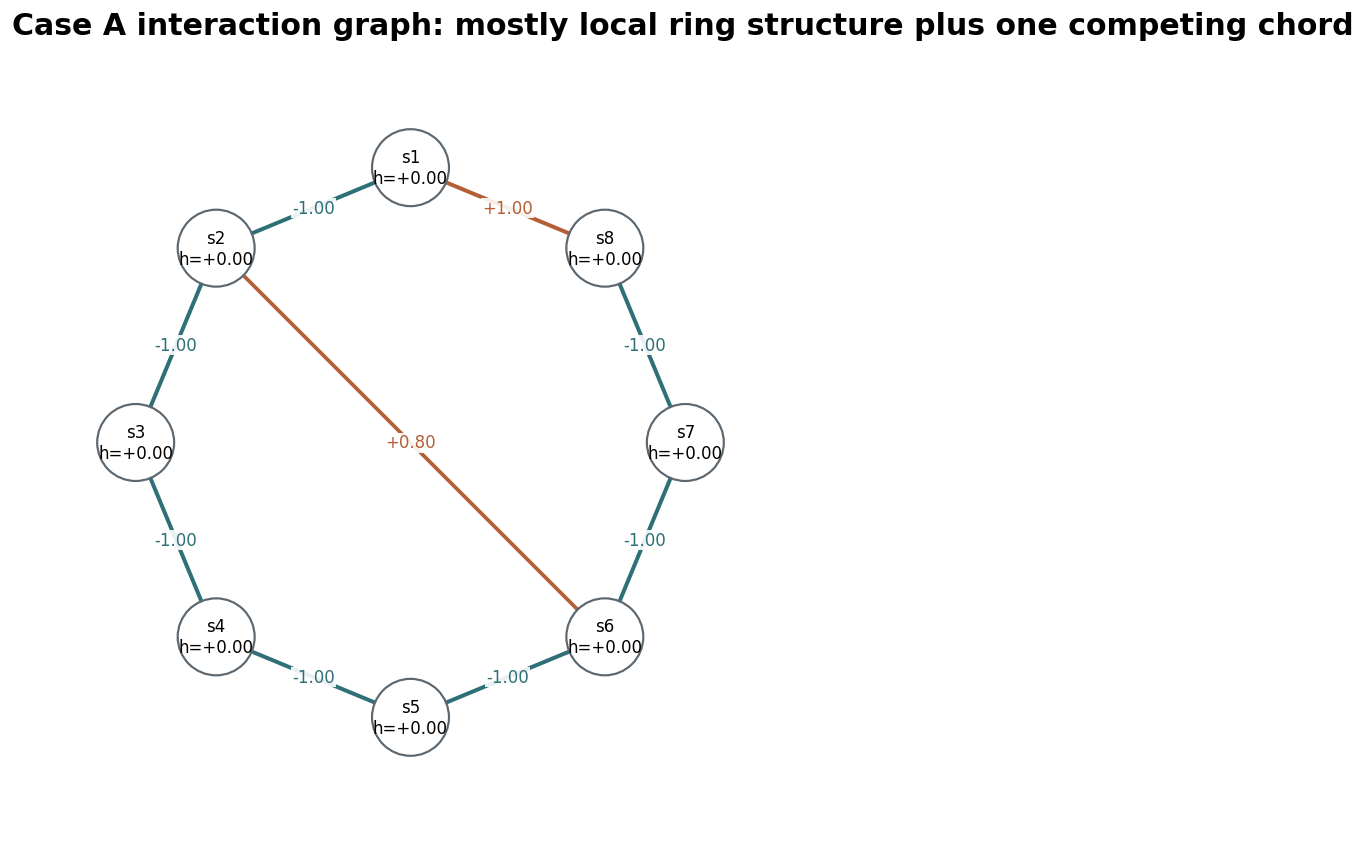

In [22]:
case_a_graph = build_interaction_graph(case_a_num_spins, case_a_couplings)
case_a_positions = circular_layout(case_a_num_spins)

plot_interaction_graph(
    case_a_num_spins,
    case_a_couplings,
    h=case_a_h,
    positions=case_a_positions,
    title='Case A interaction graph: mostly local ring structure plus one competing chord',
)
plt.show()


The picture already tells us several useful things. Most interactions are local on a ring, the coupling list is sparse, and the sign pattern creates frustration rather than one globally easy alignment pattern. That is meaningful structure. It does **not** yet tell us whether a quantum implementation will beat a good classical one.

In [23]:
case_a_structure_df = pd.DataFrame(
    {
        'Feature': [
            'Sparse pairwise interactions',
            'Mostly local ring geometry',
            'Frustration from one defect bond',
            'Extra nonlocal chord',
            'Zero local fields',
        ],
        'Why it matters': [
            'The Hamiltonian is defined by a short edge list, not a dense all-to-all matrix.',
            'Local interaction structure is easier to reason about than arbitrary dense coupling.',
            'Not all interaction preferences can be satisfied simultaneously.',
            'The chord breaks the pure ring pattern and adds extra competition.',
            'All structure comes from pair couplings rather than field bias.',
        ],
        'Checklist reading': [
            'promising but still small',
            'promising for structured modeling',
            'interesting energy landscape feature',
            'mixed: useful structure, but also extra cost pressure later',
            'neutral simplification for the worked example',
        ],
    }
)
display_wrapped(case_a_structure_df)


,Feature,Why it matters,Checklist reading
0,Sparse pairwise interactions,"The Hamiltonian is defined by a short edge list, not a dense all-to-all matrix.",promising but still small
1,Mostly local ring geometry,Local interaction structure is easier to reason about than arbitrary dense coupling.,promising for structured modeling
2,Frustration from one defect bond,Not all interaction preferences can be satisfied simultaneously.,interesting energy landscape feature
3,Extra nonlocal chord,The chord breaks the pure ring pattern and adds extra competition.,"mixed: useful structure, but also extra cost pressure later"
4,Zero local fields,All structure comes from pair couplings rather than field bias.,neutral simplification for the worked example


In [24]:
display_wrapped(Markdown(markdown_box(
    '1. If this graph were dense and irregular instead, would the advantage claim become stronger or weaker at this first checklist step?',
    title='Student Question'
)))


> **Student Question:**
> 1. If this graph were dense and irregular instead, would the advantage claim become stronger or weaker at this first checklist step?

In [25]:
display_wrapped(Markdown(markdown_box(
    'Case A does have real structure: locality, sparsity, and frustration. That makes the claim worth examining further, but structure alone does not justify the word advantage.',
    title='Takeaway'
)))


> **Takeaway:**
> Case A does have real structure: locality, sparsity, and frustration. That makes the claim worth examining further, but structure alone does not justify the word advantage.

## 5. Checklist Step 2 — Complexity Meaning

**Concept question:** What does the language of this problem tell us about evaluating one candidate state, and what does it still leave open about finding the best state?

For this 8-spin worked example we can enumerate every configuration exactly. That makes the difference between **evaluation** and **optimization** visible instead of abstract.

### Prediction assessment

Quick questions to answer

- Will exact enumeration mostly clarify the claim or mostly weaken it?
- Do you expect the low-energy states to be isolated, clustered, or highly degenerate?
- What would count as a warning sign once you see the energy landscape?


In [28]:
case_a_energy_table = enumerate_ising_energies(case_a_h, case_a_couplings)
case_a_ground_energy = case_a_energy_table['energy'].min()
case_a_ground_states = case_a_energy_table[np.isclose(case_a_energy_table['energy'], case_a_ground_energy)].copy()
case_a_energy_counts = (
    case_a_energy_table.groupby('energy', as_index=False)
    .size()
    .rename(columns={'size': 'degeneracy'})
    .sort_values('energy', ignore_index=True)
)

case_a_exact_summary_df = pd.DataFrame(
    {
        'Quantity': [
            'number of spins',
            'number of listed couplings',
            'configurations in exact search',
            'ground-state energy',
            'ground-state degeneracy',
        ],
        'Value': [
            case_a_num_spins,
            len(case_a_couplings),
            len(case_a_energy_table),
            case_a_ground_energy,
            len(case_a_ground_states),
        ],
    }
)
display_wrapped(case_a_exact_summary_df)
display_wrapped(case_a_ground_states.head(8))


,Quantity,Value
0,number of spins,8
1,number of listed couplings,9
2,configurations in exact search,256
3,ground-state energy,-6.8
4,ground-state degeneracy,8


,bitstring,spins,energy
0,00000111,"(1, 1, 1, 1, 1, -1, -1, -1)",-6.8
1,00001111,"(1, 1, 1, 1, -1, -1, -1, -1)",-6.8
2,00011111,"(1, 1, 1, -1, -1, -1, -1, -1)",-6.8
3,00111111,"(1, 1, -1, -1, -1, -1, -1, -1)",-6.8
4,11000000,"(-1, -1, 1, 1, 1, 1, 1, 1)",-6.8
5,11100000,"(-1, -1, -1, 1, 1, 1, 1, 1)",-6.8
6,11110000,"(-1, -1, -1, -1, 1, 1, 1, 1)",-6.8
7,11111000,"(-1, -1, -1, -1, -1, 1, 1, 1)",-6.8


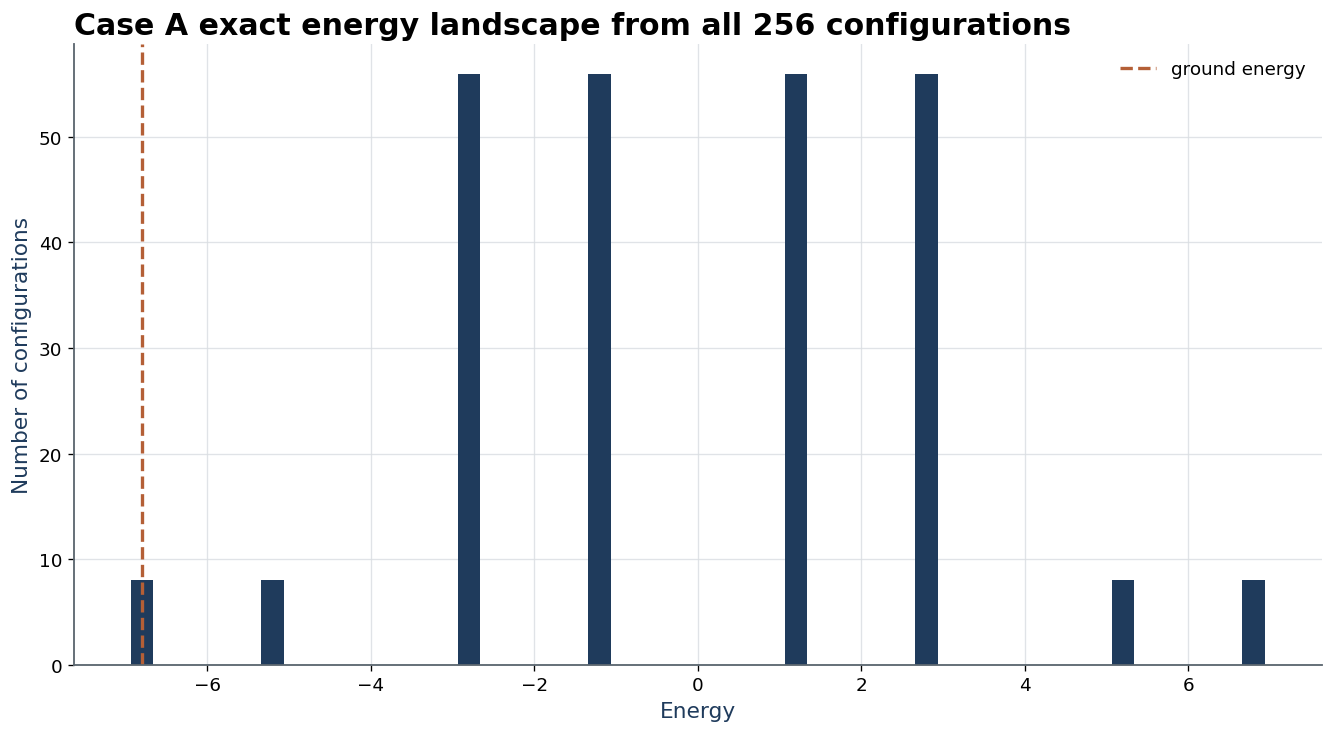

In [29]:
fig, ax = lecture_figure(kind='wide')
ax.bar(
    case_a_energy_counts['energy'],
    case_a_energy_counts['degeneracy'],
    width=0.28,
    color=COLORS['navy'],
)
ax.axvline(case_a_ground_energy, color=COLORS['rust'], linestyle='--', linewidth=2, label='ground energy')
ax.set_title('Case A exact energy landscape from all 256 configurations', loc='left')
ax.set_xlabel('Energy')
ax.set_ylabel('Number of configurations')
ax.legend(loc='upper right')
plt.show()


For $n=8$, brute force is still cheap: there are only $2^8 = 256$ spin assignments. That lets us see the full energy landscape exactly. The important complexity lesson is not that this one case is hard. The lesson is that **checking one candidate** and **searching for the best candidate** are different tasks.

In [30]:
case_a_complexity_meaning_df = pd.DataFrame(
    {
        'Task': [
            'Evaluate one proposed spin configuration',
            'Find the exact minimum by exhaustive search',
            'Claim practical advantage from Ising form alone',
        ],
        'What is fixed?': [
            'A candidate bitstring is already given.',
            'No candidate is given; we must search the space.',
            'Only the problem-class description is given.',
        ],
        'Meaning for this case': [
            'Compute the listed field and coupling terms once.',
            'Potentially inspect all 2^n configurations in a brute-force view.',
            'Still says nothing decisive about I/O, hardware cost, or baselines.',
        ],
        'Scaling signal': [
            'polynomial in spins plus listed edges',
            'exponential in n for exact brute force',
            'not a complexity proof of advantage',
        ],
    }
)
display_wrapped(case_a_complexity_meaning_df)


,Task,What is fixed?,Meaning for this case,Scaling signal
0,Evaluate one proposed spin configuration,A candidate bitstring is already given.,Compute the listed field and coupling terms once.,polynomial in spins plus listed edges
1,Find the exact minimum by exhaustive search,No candidate is given; we must search the space.,Potentially inspect all 2^n configurations in a brute-force view.,exponential in n for exact brute force
2,Claim practical advantage from Ising form alone,Only the problem-class description is given.,"Still says nothing decisive about I/O, hardware cost, or baselines.",not a complexity proof of advantage


In [31]:
display_wrapped(Markdown(markdown_box(
    '1. Why is computing H_A(s) for one proposed bitstring not the same task as finding the minimum over all bitstrings?\n'
    '2. Since n = 8 is exactly enumerable, which conclusions here are specific to this worked example and which conclusions would need new evidence before scaling up?',
    title='Student Prompt'
)))


> **Student Prompt:**
> 1. Why is computing H_A(s) for one proposed bitstring not the same task as finding the minimum over all bitstrings?
> 2. Since n = 8 is exactly enumerable, which conclusions here are specific to this worked example and which conclusions would need new evidence before scaling up?

In [32]:
display_wrapped(Markdown(markdown_box(
    'For Case A, exact enumeration is easy and useful. The complexity lesson is that Ising language separates candidate evaluation from global optimization, but it does not by itself establish a credible quantum advantage claim.',
    title='Takeaway'
)))


> **Takeaway:**
> For Case A, exact enumeration is easy and useful. The complexity lesson is that Ising language separates candidate evaluation from global optimization, but it does not by itself establish a credible quantum advantage claim.

In [33]:
case_a_checkpoint1_df = pd.DataFrame(
    {
        'Checkpoint question': [
            'Does the problem have genuine exploitable structure?',
            'Does exact enumeration make the instance feel classically fragile or classically strong?',
        ],
        'Case A evidence so far': [
            'Yes: sparse ring structure, frustration, and one competing chord.',
            f'Exact search is tiny here: {len(case_a_energy_table)} states with a fully visible energy landscape.',
        ],
        'Why this matters for the claim': [
            'Structure keeps the claim alive, at least provisionally.',
            'Easy exact search immediately raises the baseline pressure.',
        ],
    }
)
display_wrapped(case_a_checkpoint1_df)


,Checkpoint question,Case A evidence so far,Why this matters for the claim
0,Does the problem have genuine exploitable structure?,"Yes: sparse ring structure, frustration, and one competing chord.","Structure keeps the claim alive, at least provisionally."
1,Does exact enumeration make the instance feel classically fragile or classically strong?,Exact search is tiny here: 256 states with a fully visible energy landscape.,Easy exact search immediately raises the baseline pressure.


### Checkpoint After Structure + Complexity

Write a mini-verdict before you move on.
- What still makes the claim sound promising?
- What already makes you cautious?
- Has your verdict shifted since the opening hook?


## 6. Checklist Step 3 — Input Loading and Output Extraction

**Concept question:** What information must actually enter the workflow, and what kind of answer comes back out?

For Case A, the input side is fairly favorable in the notebook model: the Hamiltonian is specified by a short list of coefficients rather than a huge dense dataset. The output side is more subtle. A measurement does not return "the optimum" directly. It returns a candidate bitstring that still has to be scored classically.

### Prediction Pause

Before reading the I/O table, predict where the workflow is most vulnerable.
- Is the input side likely to be the main weakness here?
- Or is the output side more likely to erode the claim?
- What would make you change that expectation?


In [34]:
case_a_io_df = pd.DataFrame(
    {
        'Stage': [
            'Classical input description',
            'What is loaded into the workflow?',
            'One measurement outcome',
            'What classical post-processing still remains?',
        ],
        'Case A reading': [
            '8 spins, 9 listed couplings, 0 nonzero local fields.',
            'A compact Ising specification, not an arbitrary dense amplitude vector.',
            'One 8-bit candidate configuration.',
            'Score returned bitstrings, compare energies, and judge whether low-energy samples are stable or rare.',
        ],
        'Checklist implication': [
            'Input burden is mild in this toy case.',
            'The encoding story is clearer than in generic data-loading examples.',
            'Output is partial evidence, not a final proof of optimality.',
            'Useful answers still rely on repeated sampling plus classical evaluation.',
        ],
    }
)
display_wrapped(case_a_io_df)


,Stage,Case A reading,Checklist implication
0,Classical input description,"8 spins, 9 listed couplings, 0 nonzero local fields.",Input burden is mild in this toy case.
1,What is loaded into the workflow?,"A compact Ising specification, not an arbitrary dense amplitude vector.",The encoding story is clearer than in generic data-loading examples.
2,One measurement outcome,One 8-bit candidate configuration.,"Output is partial evidence, not a final proof of optimality."
3,What classical post-processing still remains?,"Score returned bitstrings, compare energies, and judge whether low-energy samples are stable or rare.",Useful answers still rely on repeated sampling plus classical evaluation.


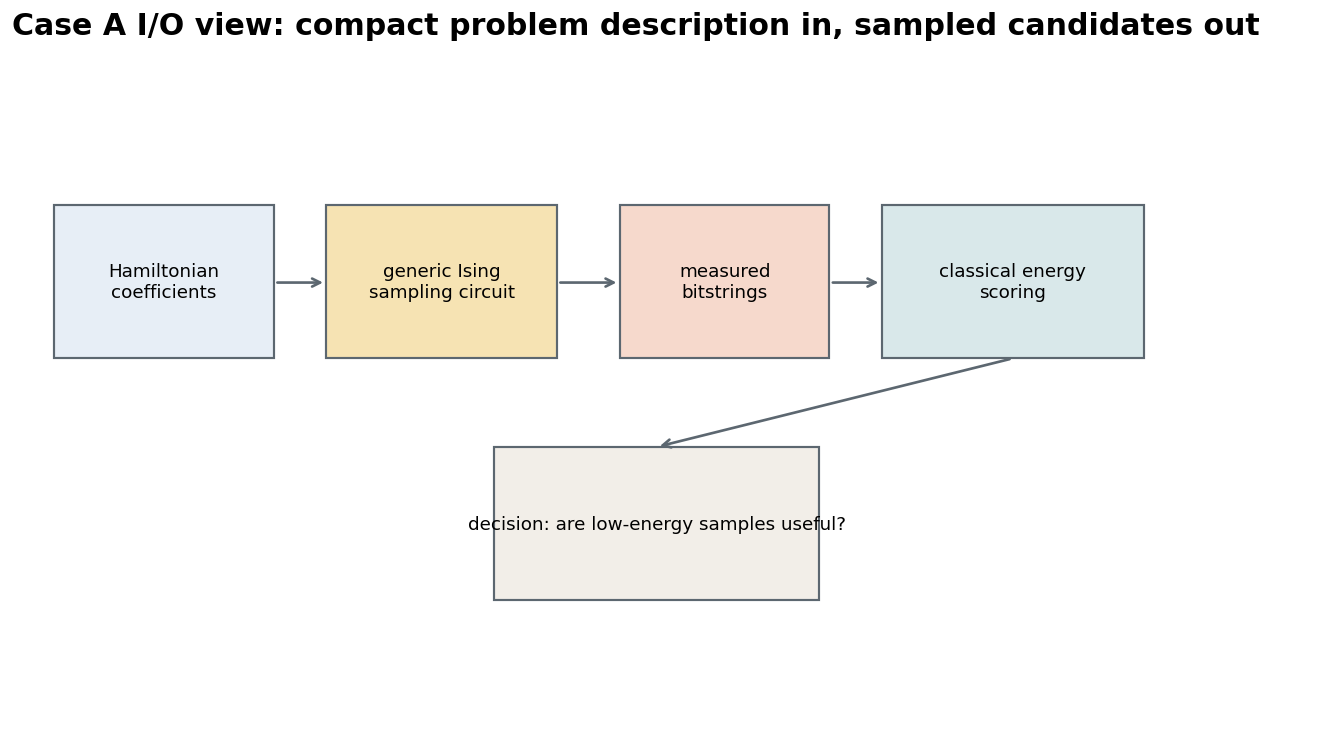

In [35]:
from matplotlib.patches import Rectangle

fig, ax = lecture_figure(kind='wide')
ax.set_xlim(0, 12.5)
ax.set_ylim(0, 4.2)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

boxes = [
    (0.4, 2.25, 2.1, 0.95, 'Hamiltonian\ncoefficients', '#e7eef6'),
    (3.0, 2.25, 2.2, 0.95, 'generic Ising\nsampling circuit', '#f6e3b3'),
    (5.8, 2.25, 2.0, 0.95, 'measured\nbitstrings', '#f6d9cc'),
    (8.3, 2.25, 2.5, 0.95, 'classical energy\nscoring', '#d9e8ea'),
    (4.6, 0.75, 3.1, 0.95, 'decision: are low-energy samples useful?', '#f2eee8'),
]

for x, y, w, h, label, color in boxes:
    rect = Rectangle((x, y), w, h, facecolor=color, edgecolor=COLORS['gray'], linewidth=1.3)
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, label, ha='center', va='center', fontsize=11)

for x0, x1 in [(2.5, 3.0), (5.2, 5.8), (7.8, 8.3)]:
    ax.annotate('', xy=(x1, 2.72), xytext=(x0, 2.72), arrowprops={'arrowstyle': '->', 'linewidth': 1.6, 'color': COLORS['gray']})
ax.annotate('', xy=(6.15, 1.7), xytext=(9.55, 2.25), arrowprops={'arrowstyle': '->', 'linewidth': 1.6, 'color': COLORS['gray']})
ax.set_title('Case A I/O view: compact problem description in, sampled candidates out', loc='left')
plt.show()


This is a comparatively friendly I/O setup because the problem is described by a short coupling list. That helps the input side of the claim. The output side is still limited: samples are only useful after classical scoring, and one sample by itself is not a convincing optimization result.

In [36]:
display_wrapped(Markdown(markdown_box(
    '1. Why is this input model more favorable than a workflow that must load a large dense classical dataset?\n'
    '2. If a device returns one candidate bitstring per shot, what extra classical work is still needed before we can interpret that output?',
    title='Student Prompt'
)))


> **Student Prompt:**
> 1. Why is this input model more favorable than a workflow that must load a large dense classical dataset?
> 2. If a device returns one candidate bitstring per shot, what extra classical work is still needed before we can interpret that output?

In [37]:
display_wrapped(Markdown(markdown_box(
    'For Case A, the input description is compact and structured. That helps. But the output is still sample-based, so usefulness depends on what bitstrings appear and how much classical scoring and repetition are required.',
    title='Takeaway'
)))


> **Takeaway:**
> For Case A, the input description is compact and structured. That helps. But the output is still sample-based, so usefulness depends on what bitstrings appear and how much classical scoring and repetition are required.

## 7. Checklist Step 4a — Generic Circuit Scaffold

**Concept question:** If we treat this as a generic Ising-sampling workflow, what are the main stages without committing to one named algorithm?

The point here is modest. We only want a hardware-agnostic scaffold for thinking about cost and output. This is **not** a full lesson on QAOA, annealing, or any other specific method.

In [38]:
case_a_scaffold_df = pd.DataFrame(
    {
        'Stage': [
            'Initialization',
            'Interaction layers',
            'Mixing / exploration layer',
            'Measurement',
            'Repeated shots',
            'Classical scoring',
        ],
        'Generic role': [
            'Prepare a simple starting state over 8 qubits.',
            'Apply two-qubit operations associated with the Ising couplings.',
            'Avoid staying trapped in one deterministic configuration.',
            'Read out a candidate bitstring in the computational basis.',
            'Collect many candidates rather than trusting one run.',
            'Compute H_A(s) for sampled bitstrings and compare energies.',
        ],
        'What it does not guarantee': [
            'That the initial state is already informative.',
            'That logical interactions are cheap on hardware.',
            'That exploration finds the true minimum efficiently.',
            'That one sample certifies optimality.',
            'That output concentration is stable enough to be useful.',
            'That the full workflow beats classical competitors.',
        ],
    }
)
display_wrapped(case_a_scaffold_df)


,Stage,Generic role,What it does not guarantee
0,Initialization,Prepare a simple starting state over 8 qubits.,That the initial state is already informative.
1,Interaction layers,Apply two-qubit operations associated with the Ising couplings.,That logical interactions are cheap on hardware.
2,Mixing / exploration layer,Avoid staying trapped in one deterministic configuration.,That exploration finds the true minimum efficiently.
3,Measurement,Read out a candidate bitstring in the computational basis.,That one sample certifies optimality.
4,Repeated shots,Collect many candidates rather than trusting one run.,That output concentration is stable enough to be useful.
5,Classical scoring,Compute H_A(s) for sampled bitstrings and compare energies.,That the full workflow beats classical competitors.


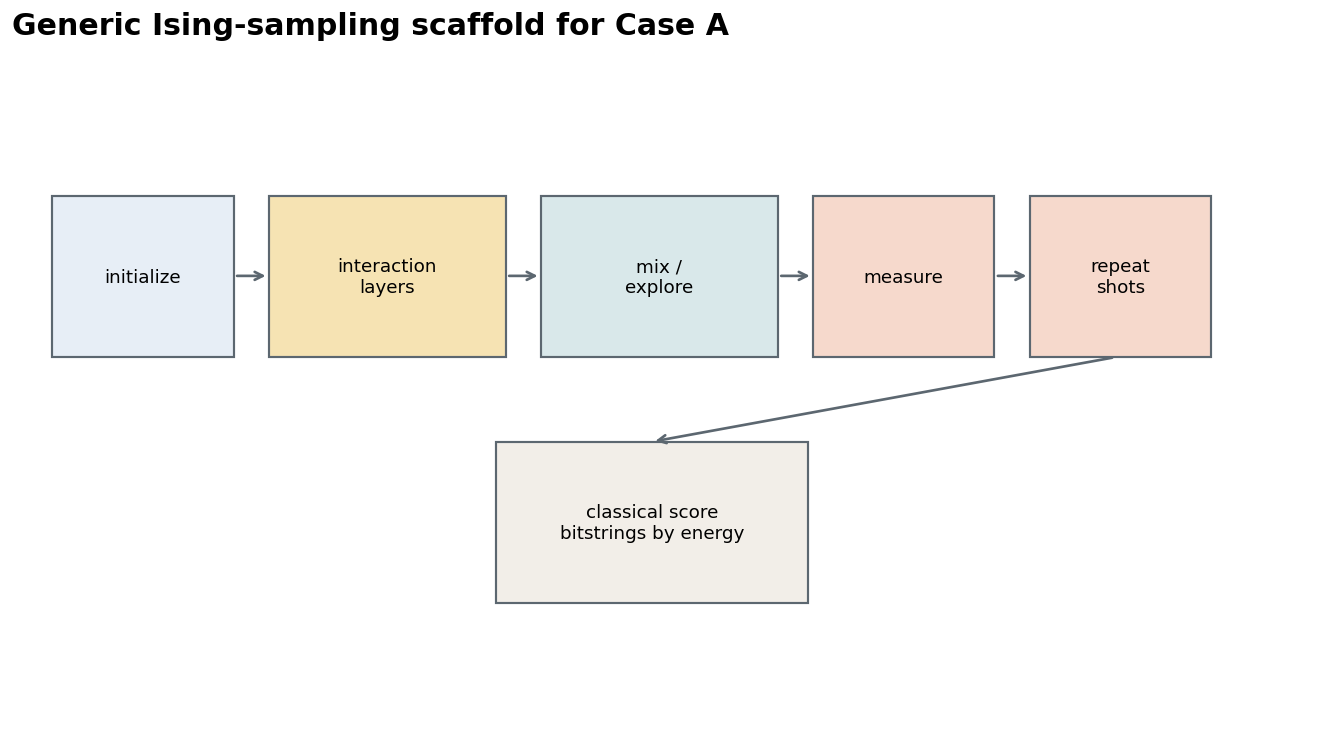

In [39]:
from matplotlib.patches import Rectangle

fig, ax = lecture_figure(kind='wide')
ax.set_xlim(0, 13)
ax.set_ylim(0, 4)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

workflow_boxes = [
    (0.4, 2.15, 1.8, 0.95, 'initialize', '#e7eef6'),
    (2.55, 2.15, 2.35, 0.95, 'interaction\nlayers', '#f6e3b3'),
    (5.25, 2.15, 2.35, 0.95, 'mix /\nexplore', '#d9e8ea'),
    (7.95, 2.15, 1.8, 0.95, 'measure', '#f6d9cc'),
    (10.1, 2.15, 1.8, 0.95, 'repeat\nshots', '#f6d9cc'),
    (4.8, 0.7, 3.1, 0.95, 'classical score\nbitstrings by energy', '#f2eee8'),
]

for x, y, w, h, label, color in workflow_boxes:
    rect = Rectangle((x, y), w, h, facecolor=color, edgecolor=COLORS['gray'], linewidth=1.3)
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, label, ha='center', va='center', fontsize=11)

for x0, x1 in [(2.2, 2.55), (4.9, 5.25), (7.6, 7.95), (9.75, 10.1)]:
    ax.annotate('', xy=(x1, 2.63), xytext=(x0, 2.63), arrowprops={'arrowstyle': '->', 'linewidth': 1.6, 'color': COLORS['gray']})
ax.annotate('', xy=(6.35, 1.65), xytext=(10.95, 2.15), arrowprops={'arrowstyle': '->', 'linewidth': 1.6, 'color': COLORS['gray']})
ax.set_title('Generic Ising-sampling scaffold for Case A', loc='left')
plt.show()


The scaffold isolates the minimal workflow logic. There is a prepared starting state, a stage that encodes the pairwise interaction terms, a stage that encourages exploration, and a measurement stage that is repeated. The returned bitstrings are then scored classically. This is enough structure for cost accounting without pretending we have already chosen or justified one specific algorithm.

In [40]:
display_wrapped(Markdown(markdown_box(
    '1. Which part of this scaffold produces candidate configurations, and which part only helps diversify what configurations may appear?\n'
    '2. Why is classical energy scoring still part of the workflow even after the quantum measurement stage?',
    title='Student Prompt'
)))


> **Student Prompt:**
> 1. Which part of this scaffold produces candidate configurations, and which part only helps diversify what configurations may appear?
> 2. Why is classical energy scoring still part of the workflow even after the quantum measurement stage?

In [41]:
display_wrapped(Markdown(markdown_box(
    'A generic Ising-sampling circuit is best read as a workflow template: prepare, interact, explore, measure, repeat, and score classically. That template helps organize costs, but it is not yet evidence that the workflow is efficient or superior.',
    title='Takeaway'
)))


> **Takeaway:**
> A generic Ising-sampling circuit is best read as a workflow template: prepare, interact, explore, measure, repeat, and score classically. That template helps organize costs, but it is not yet evidence that the workflow is efficient or superior.

In [42]:
case_a_checkpoint2_df = pd.DataFrame(
    {
        'Question': [
            'What does the workflow know on the input side?',
            'What does the circuit scaffold still leave unresolved?',
        ],
        'Case A reading': [
            'The Hamiltonian is compactly specified by a short coefficient list.',
            'A logical scaffold exists, but it says nothing yet about compilation pressure or sample reliability.',
        ],
    }
)
display_wrapped(case_a_checkpoint2_df)


,Question,Case A reading
0,What does the workflow know on the input side?,The Hamiltonian is compactly specified by a short coefficient list.
1,What does the circuit scaffold still leave unresolved?,"A logical scaffold exists, but it says nothing yet about compilation pressure or sample reliability."


### Checkpoint After I/O + Scaffold

Stop and write two sentences.
- Why is this not just a “Hamiltonian in, optimum out” story?
- Which unresolved part of the workflow now feels most dangerous: compilation, routing, or repeated sampling?


## 8. Checklist Step 4b — Logical Circuit Cost Before Hardware Compilation

**Concept question:** Before worrying about routing or topology, what interaction work does the logical problem already ask for?

Here we count only the abstract two-qubit interaction structure implied by the Case A Hamiltonian. This is still a **logical** estimate. No hardware compilation or routing overhead is included yet.

In [43]:
case_a_logical_edges = sorted(case_a_couplings)
case_a_logical_layers = greedy_edge_layers(case_a_logical_edges)

case_a_logical_interaction_df = pd.DataFrame(
    [
        {
            'interaction': f's{u + 1} s{v + 1}',
            'coupling': case_a_couplings[(u, v)],
            'kind': 'ring' if (u, v) in case_a_ring_couplings else 'chord',
        }
        for (u, v) in case_a_logical_edges
    ]
)

case_a_layer_rows = []
for layer_index, layer in enumerate(case_a_logical_layers, start=1):
    for u, v in layer:
        case_a_layer_rows.append(
            {
                'layer': layer_index,
                'interaction': f's{u + 1} s{v + 1}',
                'left_qubit': u + 1,
                'right_qubit': v + 1,
                'span': abs(v - u),
                'kind': 'ring' if (u, v) in case_a_ring_couplings else 'chord',
            }
        )
case_a_layer_df = pd.DataFrame(case_a_layer_rows)

case_a_logical_cost_df = pd.DataFrame(
    {
        'Quantity': [
            'logical qubits',
            'two-qubit interaction terms',
            'greedy parallel interaction layers',
            'logical two-qubit depth per interaction pass',
            'extra logical mixing layer per generic round',
        ],
        'Value': [
            case_a_num_spins,
            len(case_a_logical_edges),
            len(case_a_logical_layers),
            len(case_a_logical_layers),
            1,
        ],
        'Interpretation': [
            'One qubit per spin in this toy mapping.',
            'Each listed Ising coupling contributes one logical two-qubit interaction term.',
            'Disjoint edges can be scheduled in parallel before hardware constraints appear.',
            'This is the abstract interaction depth, not compiled device depth.',
            'The scaffold also needs one exploration step, counted separately from interaction depth.',
        ],
    }
)

display_wrapped(case_a_logical_cost_df)
display_wrapped(case_a_layer_df)


,Quantity,Value,Interpretation
0,logical qubits,8,One qubit per spin in this toy mapping.
1,two-qubit interaction terms,9,Each listed Ising coupling contributes one logical two-qubit interaction term.
2,greedy parallel interaction layers,3,Disjoint edges can be scheduled in parallel before hardware constraints appear.
3,logical two-qubit depth per interaction pass,3,"This is the abstract interaction depth, not compiled device depth."
4,extra logical mixing layer per generic round,1,"The scaffold also needs one exploration step, counted separately from interaction depth."


,layer,interaction,left_qubit,right_qubit,span,kind
0,1,s1 s2,1,2,1,ring
1,1,s3 s4,3,4,1,ring
2,1,s5 s6,5,6,1,ring
3,1,s7 s8,7,8,1,ring
4,2,s1 s8,1,8,7,ring
5,2,s2 s3,2,3,1,ring
6,2,s4 s5,4,5,1,ring
7,2,s6 s7,6,7,1,ring
8,3,s2 s6,2,6,4,chord


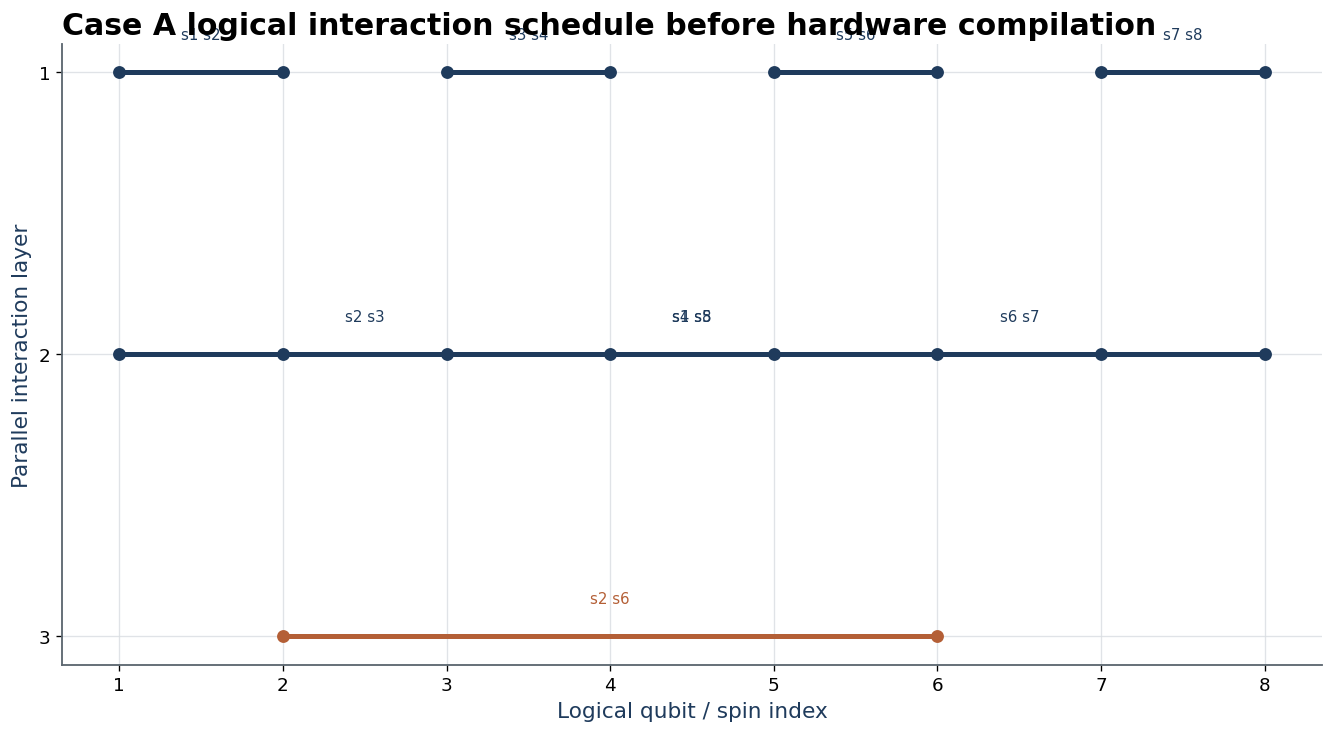

In [44]:
fig, ax = lecture_figure(kind='wide')
for _, row in case_a_layer_df.iterrows():
    left = row['left_qubit']
    right = row['right_qubit']
    color = COLORS['navy'] if row['kind'] == 'ring' else COLORS['rust']
    y = row['layer']
    ax.plot([left, right], [y, y], color=color, linewidth=3.0, solid_capstyle='round')
    ax.scatter([left, right], [y, y], color=color, s=45, zorder=3)
    ax.text((left + right) / 2, y - 0.16, row['interaction'], ha='center', va='top', fontsize=9, color=color)

ax.set_xticks(range(1, case_a_num_spins + 1))
ax.set_xlabel('Logical qubit / spin index')
ax.set_yticks(range(1, len(case_a_logical_layers) + 1))
ax.set_ylabel('Parallel interaction layer')
ax.set_title('Case A logical interaction schedule before hardware compilation', loc='left')
ax.invert_yaxis()
plt.show()


This section is deliberately narrow. It only answers: how many logical interaction terms are present, and how many non-conflicting layers are needed before hardware restrictions are considered? For Case A, the abstract interaction pattern is still quite modest. That is useful context before we later ask what compilation does to it.

In [45]:
display_wrapped(Markdown(markdown_box(
    '1. Why does logical interaction depth depend on edge conflicts even before hardware topology enters the picture?\n'
    '2. Which number in this section would still matter on an all-to-all device, and which numbers could change once hardware constraints are introduced?',
    title='Student Prompt'
)))


> **Student Prompt:**
> 1. Why does logical interaction depth depend on edge conflicts even before hardware topology enters the picture?
> 2. Which number in this section would still matter on an all-to-all device, and which numbers could change once hardware constraints are introduced?

In [46]:
display_wrapped(Markdown(markdown_box(
    'Before hardware compilation, Case A asks for 9 logical two-qubit interactions arranged into a small number of parallel layers. That logical cost is still manageable here, but it is only the starting point for later hardware-aware analysis.',
    title='Takeaway'
)))


> **Takeaway:**
> Before hardware compilation, Case A asks for 9 logical two-qubit interactions arranged into a small number of parallel layers. That logical cost is still manageable here, but it is only the starting point for later hardware-aware analysis.

## 9. Checklist Step 4c — Transpilation Mini-Module

**Concept question:** Once the logical interaction list is fixed, how do hardware connectivity constraints change the cost picture?

This mini-module uses a deliberately simple routing model. It is **not** a real transpiler. For each logical interaction edge, we measure shortest-path distance on a device graph and assign a rough compiled two-qubit cost `2d - 1`, where `d` is the device distance. Adjacent interactions cost `1`; distant interactions cost more.

In [47]:
case_a_topologies = ['all_to_all', 'ring', 'line']
case_a_routing_rows = []

for topology in case_a_topologies:
    device_graph = build_device_graph(case_a_num_spins, topology)
    for edge in case_a_logical_edges:
        u, v = edge
        distance = shortest_path_distance(device_graph, u, v)
        case_a_routing_rows.append(
            {
                'topology': topology.replace('_', '-'),
                'interaction': f's{u + 1} s{v + 1}',
                'distance': distance,
                'compiled_two_qubit_cost': rough_compiled_edge_cost(edge, device_graph),
                'direct_support': distance == 1,
            }
        )

case_a_routing_df = pd.DataFrame(case_a_routing_rows)
case_a_transpile_summary_df = (
    case_a_routing_df.groupby('topology', as_index=False)
    .agg(
        logical_interactions=('interaction', 'count'),
        directly_supported=('direct_support', 'sum'),
        mean_distance=('distance', 'mean'),
        total_compiled_two_qubit_cost=('compiled_two_qubit_cost', 'sum'),
    )
)
display_wrapped(case_a_transpile_summary_df)
display_wrapped(case_a_routing_df[case_a_routing_df['topology'] == 'line'])


,topology,logical_interactions,directly_supported,mean_distance,total_compiled_two_qubit_cost
0,all-to-all,9,9,1,9
1,line,9,7,2,27
2,ring,9,8,1.33,15


,topology,interaction,distance,compiled_two_qubit_cost,direct_support
18,line,s1 s2,1,1,True
19,line,s1 s8,7,13,False
20,line,s2 s3,1,1,True
21,line,s2 s6,4,7,False
22,line,s3 s4,1,1,True
23,line,s4 s5,1,1,True
24,line,s5 s6,1,1,True
25,line,s6 s7,1,1,True
26,line,s7 s8,1,1,True


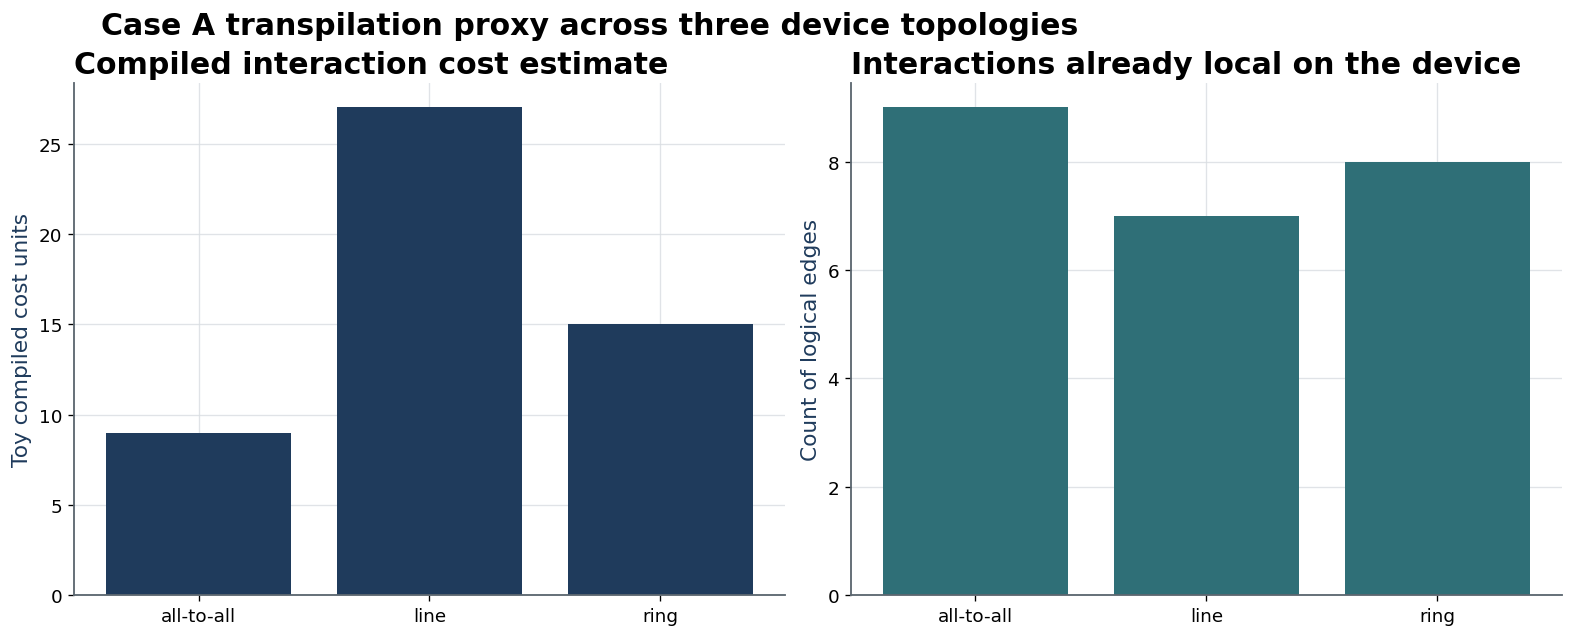

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2), constrained_layout=True)
topology_labels = case_a_transpile_summary_df['topology'].tolist()
x = np.arange(len(topology_labels))

axes[0].bar(x, case_a_transpile_summary_df['total_compiled_two_qubit_cost'], color=COLORS['navy'])
axes[0].set_xticks(x)
axes[0].set_xticklabels(topology_labels)
axes[0].set_ylabel('Toy compiled cost units')
axes[0].set_title('Compiled interaction cost estimate', loc='left')

axes[1].bar(x, case_a_transpile_summary_df['directly_supported'], color=COLORS['teal'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(topology_labels)
axes[1].set_ylabel('Count of logical edges')
axes[1].set_title('Interactions already local on the device', loc='left')

fig.suptitle('Case A transpilation proxy across three device topologies', x=0.06, ha='left', fontsize=18, fontweight='semibold')
plt.show()


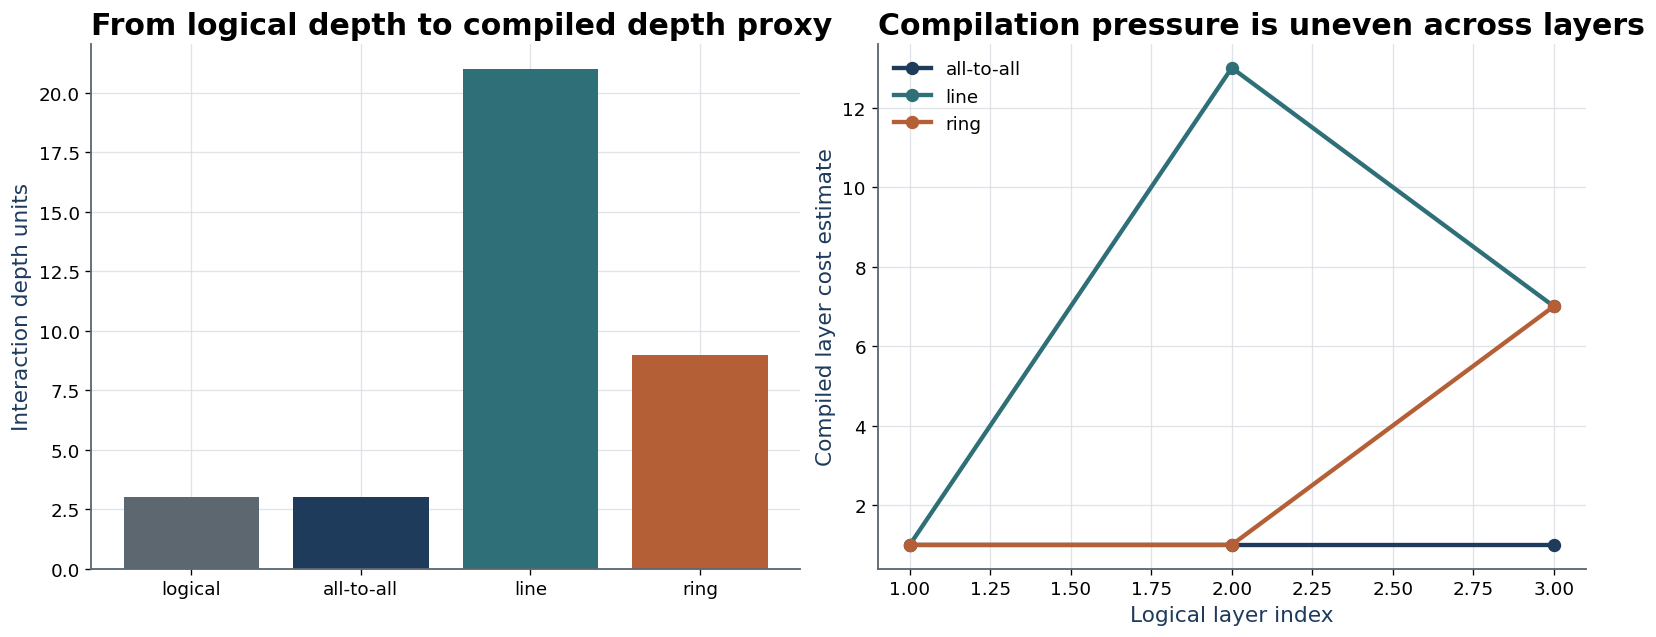

In [49]:
case_a_compiled_layer_rows = []
for topology in case_a_topologies:
    device_graph = build_device_graph(case_a_num_spins, topology)
    for layer_index, layer in enumerate(case_a_logical_layers, start=1):
        case_a_compiled_layer_rows.append(
            {
                'topology': topology.replace('_', '-'),
                'layer': layer_index,
                'compiled_layer_cost_estimate': max(rough_compiled_edge_cost(edge, device_graph) for edge in layer),
            }
        )

case_a_compiled_layer_df = pd.DataFrame(case_a_compiled_layer_rows)
case_a_compiled_depth_df = (
    case_a_compiled_layer_df.groupby('topology', as_index=False)
    .agg(compiled_depth_estimate=('compiled_layer_cost_estimate', 'sum'))
)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2), constrained_layout=True)
labels = ['logical'] + case_a_compiled_depth_df['topology'].tolist()
values = [len(case_a_logical_layers)] + case_a_compiled_depth_df['compiled_depth_estimate'].tolist()
colors = [COLORS['gray'], COLORS['navy'], COLORS['teal'], COLORS['rust']]
axes[0].bar(labels, values, color=colors)
axes[0].set_ylabel('Interaction depth units')
axes[0].set_title('From logical depth to compiled depth proxy', loc='left')

for topology, subset in case_a_compiled_layer_df.groupby('topology'):
    axes[1].plot(subset['layer'], subset['compiled_layer_cost_estimate'], marker='o', label=topology)
axes[1].set_xlabel('Logical layer index')
axes[1].set_ylabel('Compiled layer cost estimate')
axes[1].set_title('Compilation pressure is uneven across layers', loc='left')
axes[1].legend(loc='upper left')
plt.show()


Notice the change in viewpoint. The logical schedule asks only how many non-conflicting interaction layers exist. The compiled view asks how expensive each of those layers becomes once a device topology forces some interactions to travel farther than others.


The lesson is comparative, not predictive. The same logical interaction graph is almost free to place on an all-to-all device, moderately constrained on a ring, and noticeably more expensive on a line. That does not prove failure. It shows that hardware compilation can materially change the story even for a small worked example.

In [50]:
display_wrapped(Markdown(markdown_box(
    '1. Which logical interaction in Case A is most expensive on a line, and why?\n'
    '2. Why should we compare the same logical circuit across multiple device graphs before making strong claims about practical cost?',
    title='Student Prompt'
)))


> **Student Prompt:**
> 1. Which logical interaction in Case A is most expensive on a line, and why?
> 2. Why should we compare the same logical circuit across multiple device graphs before making strong claims about practical cost?

In [51]:
display_wrapped(Markdown(markdown_box(
    'Even this simple routing proxy shows that compiled cost depends strongly on hardware connectivity. Case A remains small, but topology already affects how credible a low-overhead implementation would be.',
    title='Takeaway'
)))


> **Takeaway:**
> Even this simple routing proxy shows that compiled cost depends strongly on hardware connectivity. Case A remains small, but topology already affects how credible a low-overhead implementation would be.

## 10. Checklist Step 4d — Shot Cost and Output Stability

**Concept question:** If the workflow returns samples rather than a certified optimum, how sensitive is the observed output quality to the number of shots?

The sampling model below is a **toy proxy** only. It biases toward lower-energy states with a simple Boltzmann-like rule so that we can reason about shot count and output stability. It is **not** a faithful simulation of QAOA, annealing, hardware noise, or any named algorithm.

In [52]:
case_a_shot_temperature = 0.75
case_a_shot_counts = [8, 16, 64, 256]
case_a_shot_seeds = [7, 11, 13, 17, 19, 23, 29, 31, 37, 41]
case_a_ground_mask = np.isclose(case_a_energy_table['energy'], case_a_ground_energy)
case_a_shifted_energy = case_a_energy_table['energy'].to_numpy(dtype=float) - case_a_energy_table['energy'].min()
case_a_proxy_weights = np.exp(-case_a_shifted_energy / case_a_shot_temperature)
case_a_proxy_probabilities = case_a_proxy_weights / case_a_proxy_weights.sum()
case_a_proxy_ground_probability = case_a_proxy_probabilities[case_a_ground_mask].sum()
case_a_shot_rows = []

for shots in case_a_shot_counts:
    for seed in case_a_shot_seeds:
        sampled_df = toy_shot_sampling_proxy(
            case_a_energy_table,
            shots=shots,
            temperature=case_a_shot_temperature,
            seed=seed,
        )
        best_seen_energy = sampled_df['energy'].min()
        ground_state_counts = int(sampled_df.loc[np.isclose(sampled_df['energy'], case_a_ground_energy), 'counts'].sum())
        ground_state_fraction = ground_state_counts / shots
        case_a_shot_rows.append(
            {
                'shots': shots,
                'seed': seed,
                'best_seen_energy': best_seen_energy,
                'ground_state_counts': ground_state_counts,
                'ground_state_fraction': ground_state_fraction,
                'ground_fraction_abs_error': abs(ground_state_fraction - case_a_proxy_ground_probability),
                'unique_bitstrings_seen': len(sampled_df),
            }
        )

case_a_shot_stability_df = pd.DataFrame(case_a_shot_rows)
case_a_shot_summary_df = (
    case_a_shot_stability_df.groupby('shots', as_index=False)
    .agg(
        mean_best_seen_energy=('best_seen_energy', 'mean'),
        mean_ground_state_fraction=('ground_state_fraction', 'mean'),
        std_ground_state_fraction=('ground_state_fraction', 'std'),
        mean_abs_ground_fraction_error=('ground_fraction_abs_error', 'mean'),
        mean_unique_bitstrings_seen=('unique_bitstrings_seen', 'mean'),
    )
)
case_a_shot_summary_df['toy_ground_probability'] = case_a_proxy_ground_probability
display_wrapped(case_a_shot_summary_df)


,shots,mean_best_seen_energy,mean_ground_state_fraction,std_ground_state_fraction,mean_abs_ground_fraction_error,mean_unique_bitstrings_seen,toy_ground_probability
0,8,-6.8,0.887,0.0922,0.0687,5.4,0.865
1,16,-6.8,0.881,0.0748,0.0604,8.4,0.865
2,64,-6.8,0.878,0.0482,0.0416,13.6,0.865
3,256,-6.8,0.871,0.0186,0.0165,23.3,0.865


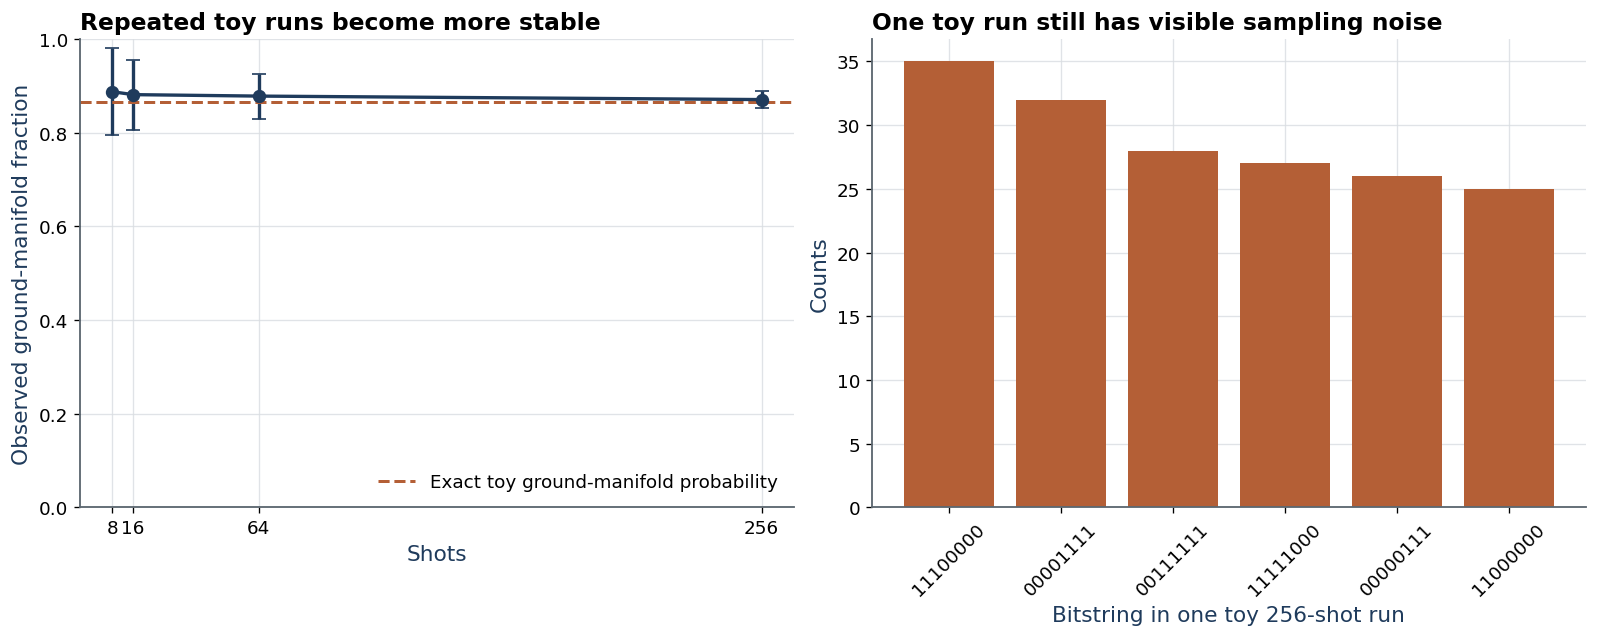

In [53]:
case_a_proxy_256_df = toy_shot_sampling_proxy(
    case_a_energy_table,
    shots=256,
    temperature=case_a_shot_temperature,
    seed=LAB_SEED,
)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2), constrained_layout=True)
axes[0].errorbar(
    case_a_shot_summary_df['shots'],
    case_a_shot_summary_df['mean_ground_state_fraction'],
    yerr=case_a_shot_summary_df['std_ground_state_fraction'],
    marker='o',
    capsize=4,
    color=COLORS['navy'],
    linewidth=2,
)
axes[0].axhline(
    case_a_proxy_ground_probability,
    linestyle='--',
    linewidth=1.8,
    color=COLORS['rust'],
    label='Exact toy ground-manifold probability',
)
axes[0].set_xticks(case_a_shot_counts)
axes[0].set_ylim(0, 1.0)
axes[0].set_xlabel('Shots')
axes[0].set_ylabel('Observed ground-manifold fraction')
axes[0].set_title('Repeated toy runs become more stable', loc='left', fontsize=14)
axes[0].legend(frameon=False, loc='lower right')

top_proxy = case_a_proxy_256_df.head(6)
axes[1].bar(top_proxy['bitstring'], top_proxy['counts'], color=COLORS['rust'])
axes[1].set_xlabel('Bitstring in one toy 256-shot run')
axes[1].set_ylabel('Counts')
axes[1].set_title('One toy run still has visible sampling noise', loc='left', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.show()


The useful quantity here is not a yes-or-no hit rate. In Case A the toy distribution already places most of its weight on an **8-state ground manifold**, so even a small number of shots usually finds at least one ground state.

The more informative question is whether repeated runs return a **similar fraction of ground-manifold samples**. As the shot count grows, that fraction fluctuates less from run to run and approaches the exact toy expectation more reliably.

A useful analogy is repeated measurement in a lab experiment: one readout can be surprising, but a stable conclusion comes from many repeated preparations and measurements. In the same way, one low-energy sample is suggestive, while a repeatable concentration of low-energy samples is much more informative. That tradeoff belongs inside the advantage discussion.


In [54]:
display_wrapped(Markdown(markdown_box(
    '1. Why does a sample-based output model force us to think about stability, not just the best bitstring seen once?\n'
    '2. If two workflows reach similar low energies but one needs many more shots to do so reliably, how should that affect the final audit?',
    title='Student Prompt'
)))


> **Student Prompt:**
> 1. Why does a sample-based output model force us to think about stability, not just the best bitstring seen once?
> 2. If two workflows reach similar low energies but one needs many more shots to do so reliably, how should that affect the final audit?

In [55]:
display_wrapped(Markdown(markdown_box(
    'Toy shot analysis reinforces a simple lesson: sample quality is part of the cost story. A low-energy bitstring is more persuasive when it appears reliably, not only once.',
    title='Takeaway'
)))


> **Takeaway:**
> Toy shot analysis reinforces a simple lesson: sample quality is part of the cost story. A low-energy bitstring is more persuasive when it appears reliably, not only once.

In [56]:
case_a_checkpoint3_df = pd.DataFrame(
    {
        'Pressure point': [
            'Transpilation / routing',
            'Shot-based output stability',
        ],
        'Case A evidence': [
            'The same logical circuit looks easy on all-to-all and noticeably heavier on a line.',
            'Low-energy samples become more persuasive when they recur across repeated toy runs, not only once.',
        ],
        'So what?': [
            'A small logical circuit can still inherit hardware pressure.',
            'A sample-based story needs stability, not only a lucky outcome.',
        ],
    }
)
display_wrapped(case_a_checkpoint3_df)


,Pressure point,Case A evidence,So what?
0,Transpilation / routing,The same logical circuit looks easy on all-to-all and noticeably heavier on a line.,A small logical circuit can still inherit hardware pressure.
1,Shot-based output stability,"Low-energy samples become more persuasive when they recur across repeated toy runs, not only once.","A sample-based story needs stability, not only a lucky outcome."


### Checkpoint After Compilation + Shots

Write a provisional verdict before looking at the classical baselines.
- If you ignored the baseline question, how strong would the claim look right now?
- What single piece of evidence from the last two sections most changed your intuition?


## 11. Checklist Step 5 — Classical Baselines

**Concept question:** What is the right classical comparison for this small worked example?

For Case A, the fair baseline is not a weak heuristic alone. Because the instance is tiny, we can solve it exactly by enumeration. A simple local-search baseline is still useful, but only as a secondary reference for workflow behavior rather than as the strongest standard.

In [57]:
case_a_local_search = local_search_baseline(case_a_h, case_a_couplings, n_restarts=32, seed=LAB_SEED)
case_a_local_search_summary = case_a_local_search['summary'].copy()
case_a_local_search_hit_rate = float(np.mean(np.isclose(case_a_local_search_summary['final_energy'], case_a_ground_energy)))

case_a_baseline_df = pd.DataFrame(
    {
        'Baseline': [
            'Exact enumeration',
            'Multi-start local search (32 restarts)',
        ],
        'What it returns': [
            'Full energy table and certified ground states.',
            'Best local minimum found over several random starts.',
        ],
        'Case A result': [
            f'Exact ground energy {case_a_ground_energy:.1f} with {len(case_a_ground_states)} ground states.',
            f'Best energy {case_a_local_search["best_energy"]:.1f}; ground-state hit rate {case_a_local_search_hit_rate:.2f}.',
        ],
        'Checklist reading': [
            'strongest fair baseline for this small instance',
            'useful secondary baseline, but not stronger than exact search here',
        ],
    }
)
display_wrapped(case_a_baseline_df)
display_wrapped(case_a_local_search_summary.head(10))


,Baseline,What it returns,Case A result,Checklist reading
0,Exact enumeration,Full energy table and certified ground states.,Exact ground energy -6.8 with 8 ground states.,strongest fair baseline for this small instance
1,Multi-start local search (32 restarts),Best local minimum found over several random starts.,Best energy -6.8; ground-state hit rate 0.69.,"useful secondary baseline, but not stronger than exact search here"


,restart,start_bitstring,final_bitstring,final_energy,steps
0,6,11100100,11100000,-6.8,1
1,7,00101111,00001111,-6.8,1
2,27,01000000,11000000,-6.8,1
3,1,11100110,11100000,-6.8,2
4,2,10110111,00111111,-6.8,2
5,3,01011000,11111000,-6.8,2
6,10,01001000,11000000,-6.8,2
7,11,00101110,00001111,-6.8,2
8,14,10110010,11110000,-6.8,2
9,15,10100001,11100000,-6.8,2


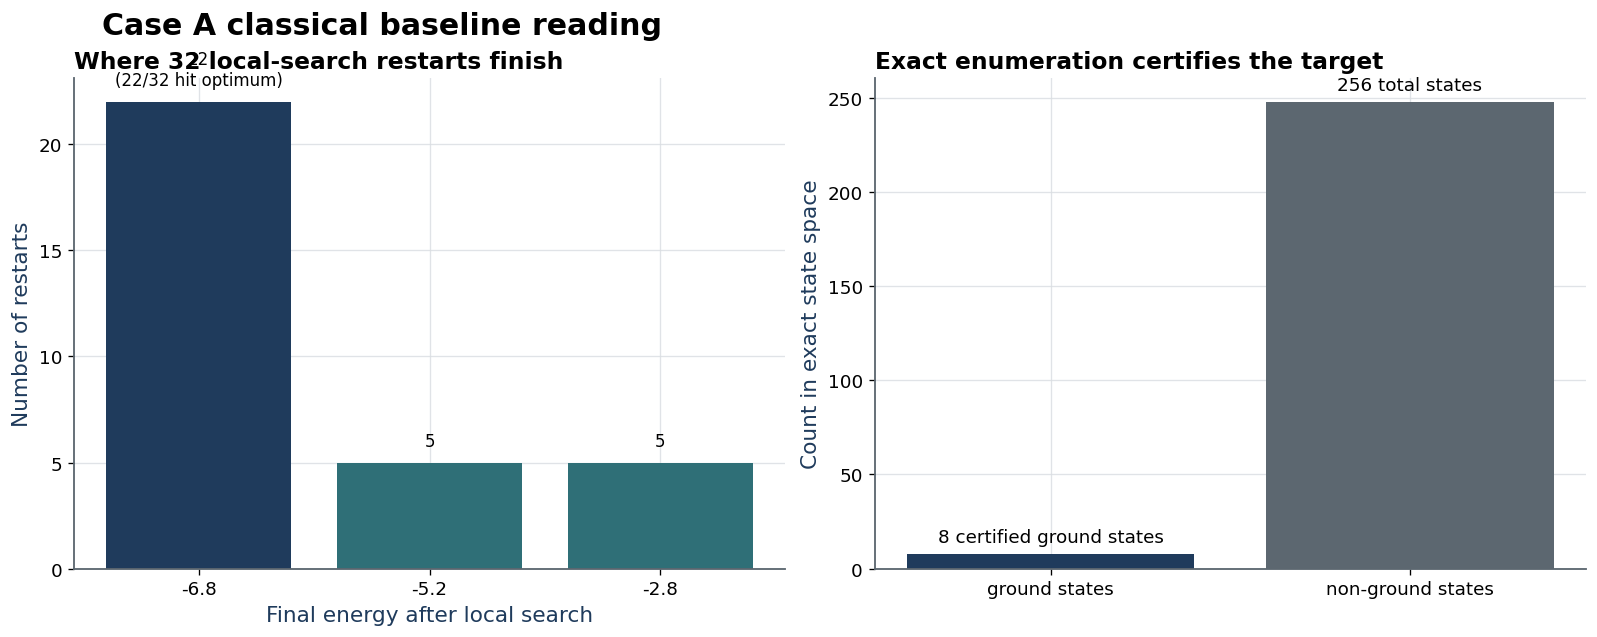

In [58]:
case_a_local_energy_counts = (
    case_a_local_search_summary.groupby('final_energy').size().reset_index(name='restart_count')
)
case_a_local_energy_counts['is_ground_energy'] = np.isclose(
    case_a_local_energy_counts['final_energy'],
    case_a_ground_energy,
)
case_a_local_colors = [
    COLORS['navy'] if is_ground else COLORS['teal']
    for is_ground in case_a_local_energy_counts['is_ground_energy']
]

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2), constrained_layout=True)

bars = axes[0].bar(
    case_a_local_energy_counts['final_energy'].astype(str),
    case_a_local_energy_counts['restart_count'],
    color=case_a_local_colors,
)
axes[0].set_xlabel('Final energy after local search')
axes[0].set_ylabel('Number of restarts')
axes[0].set_title('Where 32 local-search restarts finish', loc='left', fontsize=14)
for bar, (_, row) in zip(bars, case_a_local_energy_counts.iterrows()):
    label = f"{int(row['restart_count'])}"
    if row['is_ground_energy']:
        label += f"\n({int(row['restart_count'])}/32 hit optimum)"
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        label,
        ha='center',
        va='bottom',
        fontsize=10,
    )

axes[1].bar(
    ['ground states', 'non-ground states'],
    [len(case_a_ground_states), len(case_a_energy_table) - len(case_a_ground_states)],
    color=[COLORS['navy'], COLORS['gray']],
)
axes[1].set_ylabel('Count in exact state space')
axes[1].set_title('Exact enumeration certifies the target', loc='left', fontsize=14)
axes[1].text(
    0,
    len(case_a_ground_states) + 4,
    f'{len(case_a_ground_states)} certified ground states',
    ha='center',
    va='bottom',
    fontsize=11,
)
axes[1].text(
    1,
    len(case_a_energy_table) - len(case_a_ground_states) + 4,
    f'{len(case_a_energy_table)} total states',
    ha='center',
    va='bottom',
    fontsize=11,
)

fig.suptitle('Case A classical baseline reading', x=0.06, ha='left', fontsize=18, fontweight='semibold')
plt.show()


This plot asks two different baseline questions.

- On the left: if we run the modest classical heuristic many times, how often does it actually land on the optimum?
- On the right: what does exact enumeration certify about the full 8-spin state space?

For Case A, exact enumeration is the decisive baseline because the space has only `256` states and it certifies the ground energy directly. The local-search baseline is still useful, but its real lesson is that even a simple classical method already reaches the optimum in many runs, so advantage language faces a high bar.


In [59]:
display_wrapped(Markdown(markdown_box(
    '1. Why is exact enumeration the primary classical baseline for Case A instead of local search alone?\n'
    '2. If a toy quantum workflow only matches what exact classical search already does easily on this instance, what should that do to the advantage claim?',
    title='Student Prompt'
)))


> **Student Prompt:**
> 1. Why is exact enumeration the primary classical baseline for Case A instead of local search alone?
> 2. If a toy quantum workflow only matches what exact classical search already does easily on this instance, what should that do to the advantage claim?

In [60]:
display_wrapped(Markdown(markdown_box(
    'A persuasive quantum-advantage claim needs a fair classical comparator. For Case A, exact enumeration is already easy, so the baseline pressure is strong and unfavorable to any dramatic advantage language.',
    title='Takeaway'
)))


> **Takeaway:**
> A persuasive quantum-advantage claim needs a fair classical comparator. For Case A, exact enumeration is already easy, so the baseline pressure is strong and unfavorable to any dramatic advantage language.

### Pre-Verdict Pause

Before reading the guided verdict, write your own.
- Does the claim still feel alive, weakened, or mostly defeated?
- Which checklist step carried the most weight in that decision?
- What caveat would you insist on stating out loud?


## 12. Checklist Step 6 — Guided Verdict for Case A

**Concept question:** After structure, complexity, I/O, logical cost, transpilation pressure, shot stability, and classical baselines, how strong is the end-to-end case for meaningful advantage here?

The goal is not to assign a theatrical label. The goal is to justify a measured verdict with evidence from the earlier sections.

In [61]:
all_to_all_cost = int(case_a_transpile_summary_df.loc[case_a_transpile_summary_df['topology'] == 'all-to-all', 'total_compiled_two_qubit_cost'].iloc[0])
line_cost = int(case_a_transpile_summary_df.loc[case_a_transpile_summary_df['topology'] == 'line', 'total_compiled_two_qubit_cost'].iloc[0])

case_a_audit_df = pd.DataFrame(
    {
        'Checklist step': [
            '1. Problem structure',
            '2. Complexity meaning',
            '3. Input / output model',
            '4. Logical + compiled cost',
            '5. Classical baseline',
            '6. End-to-end verdict',
        ],
        'Case A reading': [
            'meaningful structure: sparse, local, frustrated',
            'evaluation is easy; exact optimization is also easy at n = 8',
            'compact input, but sample-based output still needs scoring and repetition',
            f'compiled toy cost rises from {all_to_all_cost} on all-to-all to {line_cost} on a line',
            'exact classical search already solves the full instance comfortably',
            'structured and instructive, but weak as a meaningful advantage case',
        ],
        'Why': [
            'The Hamiltonian is not arbitrary noise; it has real physical organization.',
            'The worked example teaches the evaluation-vs-optimization distinction, but does not create hard classical pressure.',
            'Returned bitstrings are only useful after classical energy evaluation.',
            'Hardware connectivity can magnify cost even when the logical circuit is modest.',
            'A strong claim must beat or at least seriously challenge the strongest fair classical method.',
            'The evidence supports cautious study value, not a persuasive practical speedup claim.',
        ],
    }
)
display_wrapped(case_a_audit_df)


,Checklist step,Case A reading,Why
0,1. Problem structure,"meaningful structure: sparse, local, frustrated",The Hamiltonian is not arbitrary noise; it has real physical organization.
1,2. Complexity meaning,evaluation is easy; exact optimization is also easy at n = 8,"The worked example teaches the evaluation-vs-optimization distinction, but does not create hard classical pressure."
2,3. Input / output model,"compact input, but sample-based output still needs scoring and repetition",Returned bitstrings are only useful after classical energy evaluation.
3,4. Logical + compiled cost,compiled toy cost rises from 9 on all-to-all to 27 on a line,Hardware connectivity can magnify cost even when the logical circuit is modest.
4,5. Classical baseline,exact classical search already solves the full instance comfortably,A strong claim must beat or at least seriously challenge the strongest fair classical method.
5,6. End-to-end verdict,"structured and instructive, but weak as a meaningful advantage case","The evidence supports cautious study value, not a persuasive practical speedup claim."


In [62]:
display_wrapped(Markdown(markdown_box(
    'Guided verdict for Case A: the claim is **not** strongly supported as a meaningful quantum-advantage case. The instance has genuine structure and is useful for learning the checklist, but it is too small and too classically manageable for the end-to-end advantage case to look persuasive. A careful reading is: structurally interesting, pedagogically valuable, but weak evidence for practical advantage.',
    title='Guided Verdict'
)))


> **Guided Verdict:**
> Guided verdict for Case A: the claim is **not** strongly supported as a meaningful quantum-advantage case. The instance has genuine structure and is useful for learning the checklist, but it is too small and too classically manageable for the end-to-end advantage case to look persuasive. A careful reading is: structurally interesting, pedagogically valuable, but weak evidence for practical advantage.

In [63]:
display_wrapped(Markdown(markdown_box(
    'Which checklist item weakened the claim the most for you in Case A: classical baselines, compiled cost on sparse devices, or sample-based output quality? Explain in one or two evidence-based sentences.',
    title='Student Prompt'
)))


> **Student Prompt:**
> Which checklist item weakened the claim the most for you in Case A: classical baselines, compiled cost on sparse devices, or sample-based output quality? Explain in one or two evidence-based sentences.

## 13. Problem B: Stronger Independent Case

Case B is intentionally richer than Case A. It keeps a ring-like core, adds selected next-nearest-neighbor couplings, includes nonzero local fields, and imposes explicit resource limits.

Use the Hamiltonian

$$
H_B(s) = \sum_i h_i s_i + \sum_i J^{(1)}_{i,i+1} s_i s_{i+1} + J_{1,3} s_1 s_3 + J_{4,6} s_4 s_6 + J_{7,9} s_7 s_9 + J_{2,6} s_2 s_6,
$$

with periodic indexing $s_{11} \equiv s_1$ and the fixed coefficients from the task statement.

**Resource limits for later checklist steps**
- maximum compiled two-qubit interaction depth budget: `12`
- shot budget: `256`

What becomes newly nontrivial here is not only the larger search space. The fields now bias individual spins, the extra couplings create several competing geometric scales, and the explicit budgets force the audit to confront practical constraints rather than only abstract structure.

From here the notebook becomes less guided. You should use the code outputs as evidence and write short conclusions in your own words.


In [64]:
# Fixed Case B instance for the student investigation.
#
# What to do in this cell:
# 1. Read the local fields and couplings carefully.
# 2. Confirm that the ring backbone, extra couplings, and budgets match the lab statement.
# 3. Use the two summary tables below as your reference data for the rest of Case B.
#
# Suggested outputs:
# - `case_b_resource_df` with columns ['Resource / quantity', 'Value']
# - `case_b_interactions_df` with columns ['term', 'coupling', 'kind']

case_b_num_spins = 10
case_b_h = np.array([0.2, 0.0, -0.1, 0.1, 0.0, -0.2, 0.0, 0.15, 0.0, -0.15], dtype=float)

case_b_ring_couplings = {
    canonical_edge(i, i + 1): -1.0 for i in range(case_b_num_spins - 1)
}
case_b_ring_couplings[canonical_edge(case_b_num_spins - 1, 0)] = 1.0

case_b_extra_couplings = {
    canonical_edge(0, 2): 0.7,
    canonical_edge(3, 5): 0.7,
    canonical_edge(6, 8): 0.7,
    canonical_edge(1, 5): 1.0,
}
case_b_couplings = {**case_b_ring_couplings, **case_b_extra_couplings}

case_b_compiled_depth_budget = 12
case_b_shot_budget = 256

case_b_interactions_df = pd.DataFrame(
    [
        {
            'term': f's{u + 1} s{v + 1}',
            'coupling': weight,
            'kind': 'ring' if canonical_edge(u, v) in case_b_ring_couplings else 'extra',
        }
        for (u, v), weight in sorted(case_b_couplings.items())
    ]
)

case_b_resource_df = pd.DataFrame(
    {
        'Resource / quantity': [
            'spins',
            'nonzero local fields',
            'listed couplings',
            'compiled two-qubit depth budget',
            'shot budget',
        ],
        'Value': [
            case_b_num_spins,
            int(np.count_nonzero(case_b_h)),
            len(case_b_couplings),
            case_b_compiled_depth_budget,
            case_b_shot_budget,
        ],
    }
)

display_wrapped(case_b_resource_df)
display_wrapped(case_b_interactions_df)


,Resource / quantity,Value
0,spins,10
1,nonzero local fields,6
2,listed couplings,14
3,compiled two-qubit depth budget,12
4,shot budget,256


,term,coupling,kind
0,s1 s2,-1,ring
1,s1 s3,0.7,extra
2,s1 s10,1,ring
3,s2 s3,-1,ring
4,s2 s6,1,extra
5,s3 s4,-1,ring
6,s4 s5,-1,ring
7,s4 s6,0.7,extra
8,s5 s6,-1,ring
9,s6 s7,-1,ring


### What Should Feel Different Now?

Case B is not just a larger copy of Case A. You should expect three new pressures to matter more visibly:
- the local fields now bias individual spins,
- the extra couplings create more overlapping geometric scales,
- the explicit depth and shot budgets force you to ask whether a plausible-looking workflow still fits practical constraints.


## 14. Student Task 1 — Structure

**Your job:** inspect the Hamiltonian as a graph-structured object, not just as a list of numbers.

Focus on the following questions:
- Which parts of the coupling pattern still look ring-like?
- Which added terms make the instance richer than Case A?
- Where do you expect frustration or competing preferences to appear?

### Predict Before Plotting

Before you inspect the graph, write a short prediction.
- Which added feature will most complicate the audit: the local fields, the extra couplings, or the resource limits?
- Do you expect the richer structure to make the claim stronger, weaker, or just harder to judge?


In [65]:
# Student Task 1: build the Case B interaction graph and summarize its structure.
#
# TODO:
# 1. Use `build_interaction_graph(case_b_num_spins, case_b_couplings)`.
# 2. Use `circular_layout(case_b_num_spins)` for a stable ring-like placement.
# 3. Compute node degrees from the graph dictionary.
# 4. Replace the blank entries in `case_b_structure_df`.
# 5. Uncomment the plotting call once your graph variables are ready.
#
# Suggested outputs:
# - `case_b_graph`: adjacency dictionary
# - `case_b_positions`: plotting positions
# - `case_b_structure_df` with columns ['Quantity', 'Value']

case_b_graph = {}
case_b_positions = {}
case_b_degrees = {}

# Starter lines to complete:
# case_b_graph = build_interaction_graph(case_b_num_spins, case_b_couplings)
# case_b_positions = circular_layout(case_b_num_spins)
# case_b_degrees = {node: len(neighbors) for node, neighbors in case_b_graph.items()}

case_b_structure_df = pd.DataFrame(
    {
        'Quantity': [
            'ring couplings',
            'additional couplings',
            'maximum graph degree',
            'minimum graph degree',
            'nonzero local fields',
        ],
        'Value': [
            len(case_b_ring_couplings),
            len(case_b_extra_couplings),
            '',
            '',
            int(np.count_nonzero(case_b_h)),
        ],
    }
)
display_wrapped(case_b_structure_df)

display_wrapped(Markdown(markdown_box(
    'Next action: build `case_b_graph`, compute the missing degree values, and then uncomment a `plot_interaction_graph(...)` call in this cell so your structure evidence appears here.',
    title='Student TODO'
)))

# Uncomment after you complete the graph objects above.
# plot_interaction_graph(
#     case_b_num_spins,
#     case_b_couplings,
#     h=case_b_h,
#     positions=case_b_positions,
#     title='Case B interaction graph: ring backbone plus selected longer-range couplings',
# )
# plt.show()


,Quantity,Value
0,ring couplings,10
1,additional couplings,4
2,maximum graph degree,
3,minimum graph degree,
4,nonzero local fields,6


> **Student TODO:**
> Next action: build `case_b_graph`, compute the missing degree values, and then uncomment a `plot_interaction_graph(...)` call in this cell so your structure evidence appears here.

In [66]:
display_wrapped(Markdown(markdown_box(
    'Write 3-5 sentences. Identify at least one feature that still makes the problem structured and at least one feature that makes it more demanding than Case A. Reference the graph, the local fields, and the added couplings explicitly.',
    title='Student Task Prompt'
)))


> **Student Task Prompt:**
> Write 3-5 sentences. Identify at least one feature that still makes the problem structured and at least one feature that makes it more demanding than Case A. Reference the graph, the local fields, and the added couplings explicitly.

## 15. Student Task 2 — Complexity Meaning

**Your job:** use exact enumeration on the 10-spin space to study what is easy to evaluate, what is expensive to optimize by brute force, and what the low-energy structure looks like.

Because $2^{10} = 1024$, this case is still exactly enumerable in the notebook. That gives you a complete reference for the small instance while still making the search space visibly larger than in Case A.

In [67]:
# Student Task 2: enumerate the full 10-spin state space and extract the key exact quantities.
#
# Suggested helper:
# - `enumerate_ising_energies(...)`
#
# TODO:
# 1. Build `case_b_energy_table` with columns ['bitstring', 'spins', 'energy'].
# 2. Extract `case_b_ground_energy`.
# 3. Build `case_b_ground_states` at the minimum exact energy.
# 4. Build `case_b_low_energy_window` for states within 1.5 energy units of the ground state.
# 5. Build `case_b_energy_counts` with one row per distinct energy and a degeneracy count.
# 6. Replace the blank values in `case_b_complexity_df`.

case_b_energy_table = pd.DataFrame(columns=['bitstring', 'spins', 'energy'])
case_b_ground_energy = np.nan
case_b_ground_states = pd.DataFrame(columns=['bitstring', 'spins', 'energy'])
case_b_low_energy_window = pd.DataFrame(columns=['bitstring', 'spins', 'energy'])
case_b_energy_counts = pd.DataFrame(columns=['energy', 'degeneracy'])

# Starter lines to complete:
# case_b_energy_table = enumerate_ising_energies(case_b_h, case_b_couplings)
# case_b_ground_energy = case_b_energy_table['energy'].min()
# case_b_ground_states = case_b_energy_table[np.isclose(case_b_energy_table['energy'], case_b_ground_energy)].copy()
# case_b_low_energy_window = case_b_energy_table[case_b_energy_table['energy'] <= case_b_ground_energy + 1.5].copy()
# case_b_energy_counts = (
#     case_b_energy_table.groupby('energy', as_index=False)
#     .size()
#     .rename(columns={'size': 'degeneracy'})
#     .sort_values('energy', ignore_index=True)
# )

case_b_complexity_df = pd.DataFrame(
    {
        'Quantity': [
            'spins',
            'configurations in exact search',
            'ground-state energy',
            'ground-state degeneracy',
            'states within 1.5 energy units of the ground state',
        ],
        'Value': [
            case_b_num_spins,
            '',
            '',
            '',
            '',
        ],
    }
)
display_wrapped(case_b_complexity_df)
display_wrapped(case_b_low_energy_window.head(12))


,Quantity,Value
0,spins,10
1,configurations in exact search,
2,ground-state energy,
3,ground-state degeneracy,
4,states within 1.5 energy units of the ground state,


,bitstring,spins,energy


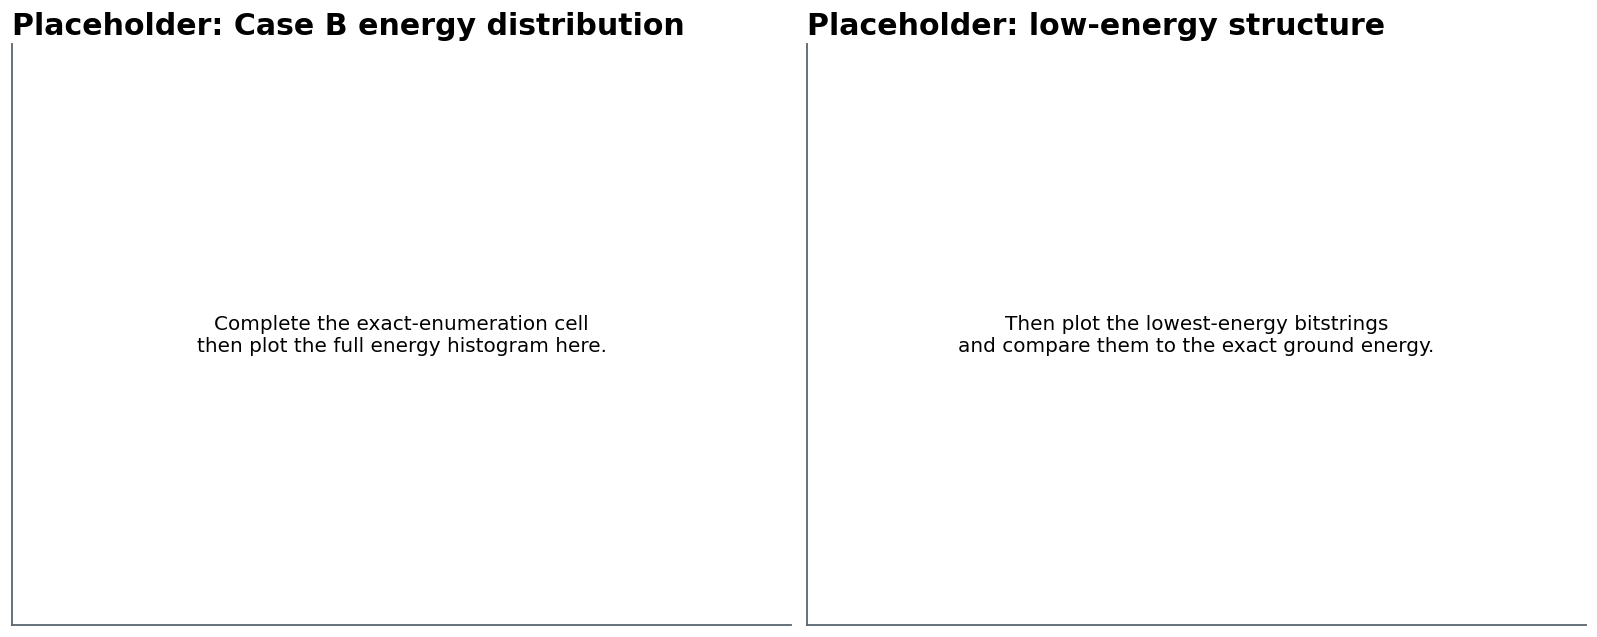

In [68]:
# Student Task 2, continued: make two evidence plots from exact enumeration.
#
# Plot 1 goal:
# - show the full energy distribution over all 1024 states.
#
# Plot 2 goal:
# - show the lowest-energy bitstrings explicitly so you can inspect near-ground structure.
#
# TODO:
# - After you complete the previous cell, replace the placeholder branches below
#   with the real histogram and low-energy bar chart.

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2), constrained_layout=True)

if case_b_energy_table.empty or pd.isna(case_b_ground_energy):
    axes[0].text(0.5, 0.5, 'Complete the exact-enumeration cell\nthen plot the full energy histogram here.', ha='center', va='center', fontsize=12)
    axes[0].set_title('Placeholder: Case B energy distribution', loc='left')
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    axes[1].text(0.5, 0.5, 'Then plot the lowest-energy bitstrings\nand compare them to the exact ground energy.', ha='center', va='center', fontsize=12)
    axes[1].set_title('Placeholder: low-energy structure', loc='left')
    axes[1].set_xticks([])
    axes[1].set_yticks([])
else:
    top_low_energy = case_b_energy_table.head(12)
    axes[0].hist(case_b_energy_table['energy'], bins=24, color=COLORS['navy'], edgecolor='white')
    axes[0].axvline(case_b_ground_energy, color=COLORS['rust'], linestyle='--', linewidth=2)
    axes[0].set_xlabel('Energy')
    axes[0].set_ylabel('Number of configurations')
    axes[0].set_title('Case B energy distribution over all 1024 states', loc='left')

    axes[1].bar(top_low_energy['bitstring'], top_low_energy['energy'], color=COLORS['teal'])
    axes[1].axhline(case_b_ground_energy, color=COLORS['rust'], linestyle='--', linewidth=2)
    axes[1].set_xlabel('Lowest-energy bitstrings found by exact enumeration')
    axes[1].set_ylabel('Energy')
    axes[1].set_title('Low-energy structure near the ground state', loc='left')
    axes[1].tick_params(axis='x', rotation=45)

plt.show()


In [69]:
display_wrapped(Markdown(markdown_box(
    'Write 4-6 sentences. Distinguish clearly between the cost of evaluating one proposed bitstring and the cost of searching the full 10-spin space. Then comment on what the histogram and the low-energy table suggest about the structure of the energy landscape near the optimum.',
    title='Student Task Prompt'
)))


> **Student Task Prompt:**
> Write 4-6 sentences. Distinguish clearly between the cost of evaluating one proposed bitstring and the cost of searching the full 10-spin space. Then comment on what the histogram and the low-energy table suggest about the structure of the energy landscape near the optimum.

In [70]:
# Student checkpoint template after the first two Case B tasks.
#
# Fill this table yourself after you inspect the graph, exact summary table, and energy plots.
# Suggested columns:
# - 'Checkpoint question'
# - 'Your evidence'
# - 'Why it matters for the claim'

case_b_checkpoint1_df = pd.DataFrame(
    {
        'Checkpoint question': [
            'What became richer than in Case A?',
            'What remained compact despite the larger search space?',
        ],
        'Your evidence': [
            '',
            '',
        ],
        'Why it matters for the claim': [
            '',
            '',
        ],
    }
)
display_wrapped(case_b_checkpoint1_df)


,Checkpoint question,Your evidence,Why it matters for the claim
0,What became richer than in Case A?,,
1,What remained compact despite the larger search space?,,


### Checkpoint After Structure + Complexity + I/O

Write 3-4 sentences.
- What now feels genuinely more difficult than in Case A?
- Which part of the claim still sounds plausible?
- Which part already feels fragile before any circuit or transpilation analysis?


## 16. Student Task 3 — Input/Output Model

**Your job:** describe what a realistic user would supply to the workflow and what the workflow would return under the current resource limits.

Keep the distinction clear:
- the **problem description** is the compact Hamiltonian data,
- the **search space** is the much larger set of possible bitstrings,
- the **output** of a sampling workflow is not the full energy table.

In [71]:
# Student Task 3: build an input/output reasoning table for Case B.
#
# This cell is mainly conceptual rather than numerical.
# Use the Case B Hamiltonian, the exact search-space size, and the resource budgets.
#
# Suggested columns:
# - 'Aspect'
# - 'Your Case B reading'
# - 'Why it matters'
#
# Fill the blank strings below with short, specific statements.

case_b_io_df = pd.DataFrame(
    {
        'Aspect': [
            'Problem description size',
            'Search space size',
            'One sampled output',
            'Total sample budget',
            'What is not returned directly',
        ],
        'Your Case B reading': [
            '',
            '',
            '',
            '',
            '',
        ],
        'Why it matters': [
            '',
            '',
            '',
            '',
            '',
        ],
    }
)
display_wrapped(case_b_io_df)


,Aspect,Your Case B reading,Why it matters
0,Problem description size,,
1,Search space size,,
2,One sampled output,,
3,Total sample budget,,
4,What is not returned directly,,


In [72]:
display_wrapped(Markdown(markdown_box(
    'Write 3-5 sentences. Explain why the Case B input description is still compact even though the search space is much larger. Then explain why a 256-shot budget does not mean that the workflow has learned the full energy landscape or certified the true optimum.',
    title='Student Task Prompt'
)))


> **Student Task Prompt:**
> Write 3-5 sentences. Explain why the Case B input description is still compact even though the search space is much larger. Then explain why a 256-shot budget does not mean that the workflow has learned the full energy landscape or certified the true optimum.

## 17. Student Task 4 — Logical Circuit Sketch

**Your job:** reuse the same generic Ising-sampling scaffold from Case A, but now apply it to Case B.

Keep the sketch algorithm-agnostic. Your answer should stay at the workflow level:
- initialization,
- interaction layers from the Ising couplings,
- a mixing / exploration layer,
- measurement,
- repeated shots,
- classical scoring of sampled bitstrings.

In [ ]:
# Student Task 4: sketch the logical Ising-sampling workflow for Case B.
#
# Suggested helper:
# - `greedy_edge_layers(...)` to estimate the logical interaction layers.
#
# TODO:
# 1. Build `case_b_logical_edges` from the Case B coupling dictionary.
# 2. Build `case_b_logical_layers` with the greedy layering helper.
# 3. Fill the scaffold table below with your own workflow description.
#
# Suggested columns:
# - 'Stage'
# - 'Your Case B sketch'
# - 'Why this stage matters'

case_b_logical_edges = []
case_b_logical_layers = []

# Starter lines to complete:
# case_b_logical_edges = sorted(case_b_couplings)
# case_b_logical_layers = greedy_edge_layers(case_b_logical_edges)

case_b_scaffold_df = pd.DataFrame(
    {
        'Stage': [
            'Initialization',
            'Interaction layers',
            'Mixing / exploration layer',
            'Measurement',
            'Repeated shots',
            'Classical scoring',
        ],
        'Your Case B sketch': [
            '',
            '',
            '',
            '',
            '',
            '',
        ],
        'Why this stage matters': [
            '',
            '',
            '',
            '',
            '',
            '',
        ],
    }
)
display_wrapped(case_b_scaffold_df)


In [ ]:
# Student Task 4, continued: run this generic workflow diagram after you fill the scaffold table.
#
# Purpose of the figure:
# - keep the workflow algorithm-agnostic,
# - separate logical interaction layers from classical scoring,
# - remind you that measurement and repeated shots are only part of the full story.

from matplotlib.patches import Rectangle

fig, ax = lecture_figure(kind='wide')
ax.set_xlim(0, 13)
ax.set_ylim(0, 4)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

workflow_boxes = [
    (0.4, 2.15, 1.8, 0.95, 'initialize', '#e7eef6'),
    (2.55, 2.15, 2.35, 0.95, 'interaction\nlayers', '#f6e3b3'),
    (5.25, 2.15, 2.35, 0.95, 'mix /\nexplore', '#d9e8ea'),
    (7.95, 2.15, 1.8, 0.95, 'measure', '#f6d9cc'),
    (10.1, 2.15, 1.8, 0.95, 'repeat\nshots', '#f6d9cc'),
    (4.8, 0.7, 3.1, 0.95, 'classical score\nbitstrings by energy', '#f2eee8'),
]

for x, y, w, h, label, color in workflow_boxes:
    rect = Rectangle((x, y), w, h, facecolor=color, edgecolor=COLORS['gray'], linewidth=1.3)
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, label, ha='center', va='center', fontsize=11)

for x0, x1 in [(2.2, 2.55), (4.9, 5.25), (7.6, 7.95), (9.75, 10.1)]:
    ax.annotate('', xy=(x1, 2.63), xytext=(x0, 2.63), arrowprops={'arrowstyle': '->', 'linewidth': 1.6, 'color': COLORS['gray']})
ax.annotate('', xy=(6.35, 1.65), xytext=(10.95, 2.15), arrowprops={'arrowstyle': '->', 'linewidth': 1.6, 'color': COLORS['gray']})
ax.set_title('Case B generic Ising-sampling scaffold', loc='left')
plt.show()


In [ ]:
display_wrapped(Markdown(markdown_box(
    'Write 4-6 sentences. Sketch the logical workflow for Case B using the six stages above. Your answer should explain what happens in each stage without naming or teaching a specific algorithm family.',
    title='Student Task Prompt'
)))


## 18. Student Task 5 — Transpilation and Compiled Cost

**Your job:** compare the same Case B logical interaction pattern across `all-to-all`, `ring`, and `line` device graphs.

Use the same transparent toy rule as before:
- each logical interaction edge is mapped onto a device graph,
- shortest-path distance gives a routing intuition,
- rough compiled cost for one edge is `2d - 1`,
- a rough compiled interaction-depth estimate is built by taking the maximum compiled edge cost inside each greedy logical layer and summing across layers.

Then ask whether that compiled-depth estimate looks plausible under the Case B budget of `12`.

In [ ]:
# Student Task 5: compute the toy transpilation evidence for Case B.
#
# Suggested helpers:
# - `build_device_graph(...)`
# - `shortest_path_distance(...)`
# - `rough_compiled_edge_cost(...)`
#
# TODO:
# 1. Use `case_b_logical_edges` from the previous task.
# 2. Build `case_b_transpile_df` with columns
#    ['topology', 'interaction', 'distance', 'compiled_two_qubit_cost', 'direct_support'].
# 3. Build `case_b_compiled_layer_df` with columns
#    ['topology', 'layer', 'interactions_in_layer', 'compiled_layer_cost_estimate'].
# 4. Build `case_b_transpile_summary_df` and `case_b_depth_budget_df`.
# 5. Decide which topology looks most plausible under the depth budget.

case_b_transpile_df = pd.DataFrame(
    columns=['topology', 'interaction', 'distance', 'compiled_two_qubit_cost', 'direct_support']
)
case_b_compiled_layer_df = pd.DataFrame(
    columns=['topology', 'layer', 'interactions_in_layer', 'compiled_layer_cost_estimate']
)
case_b_transpile_summary_df = pd.DataFrame(
    {
        'topology': ['all-to-all', 'ring', 'line'],
        'logical_interactions': ['', '', ''],
        'directly_supported': ['', '', ''],
        'mean_distance': ['', '', ''],
        'total_compiled_two_qubit_cost': ['', '', ''],
    }
)
case_b_depth_budget_df = pd.DataFrame(
    {
        'topology': ['all-to-all', 'ring', 'line'],
        'compiled_depth_estimate': ['', '', ''],
        'within_budget': ['', '', ''],
    }
)

# Starter loop outline to complete:
# case_b_transpile_rows = []
# case_b_compiled_layer_rows = []
# for topology in ['all_to_all', 'ring', 'line']:
#     device_graph = build_device_graph(case_b_num_spins, topology)
#     ...
# case_b_transpile_df = pd.DataFrame(case_b_transpile_rows)
# case_b_compiled_layer_df = pd.DataFrame(case_b_compiled_layer_rows)
# case_b_transpile_summary_df = (...)
# case_b_depth_budget_df = (...)

display_wrapped(case_b_transpile_summary_df)
display_wrapped(case_b_depth_budget_df)


In [ ]:
# Read this plot against the depth budget of 12.
# Student Task 5, continued: visualize the compiled-cost story.
#
# Plot 1 goal:
# - compare the total toy compiled interaction cost across device graphs.
#
# Plot 2 goal:
# - compare the compiled-depth estimate with the Case B budget of 12.
#
# TODO:
# - Replace the placeholder figure below after you fill `case_b_transpile_summary_df`
#   and `case_b_depth_budget_df` in the previous cell.

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2), constrained_layout=True)

summary_ready = (
    not case_b_transpile_summary_df.empty
    and pd.to_numeric(case_b_transpile_summary_df['total_compiled_two_qubit_cost'], errors='coerce').notna().all()
    and pd.to_numeric(case_b_depth_budget_df['compiled_depth_estimate'], errors='coerce').notna().all()
)

if not summary_ready:
    axes[0].text(0.5, 0.5, 'After you compute the topology summary\nplot total compiled cost here for\nall-to-all, ring, and line.', ha='center', va='center', fontsize=12)
    axes[0].set_title('Placeholder: compiled interaction cost', loc='left')
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    axes[1].text(0.5, 0.5, 'Then compare the compiled-depth estimate\nwith the budget of 12 and mark which\ntopologies look plausible.', ha='center', va='center', fontsize=12)
    axes[1].set_title('Placeholder: depth budget check', loc='left')
    axes[1].set_xticks([])
    axes[1].set_yticks([])
else:
    labels = case_b_depth_budget_df['topology'].tolist()
    x = np.arange(len(labels))

    axes[0].bar(x, pd.to_numeric(case_b_transpile_summary_df['total_compiled_two_qubit_cost']), color=COLORS['navy'])
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].set_ylabel('Toy compiled cost units')
    axes[0].set_title('Total compiled interaction cost proxy', loc='left')

    axes[1].bar(x, pd.to_numeric(case_b_depth_budget_df['compiled_depth_estimate']), color=COLORS['teal'])
    axes[1].axhline(case_b_compiled_depth_budget, color=COLORS['rust'], linestyle='--', linewidth=2, label='depth budget = 12')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_ylabel('Compiled depth estimate')
    axes[1].set_title('Does the toy compiled depth fit the budget?', loc='left')
    axes[1].legend(loc='upper right')

plt.show()


In [ ]:
display_wrapped(Markdown(markdown_box(
    'Write 4-6 sentences. Compare `all-to-all`, `ring`, and `line` for Case B. Identify which topology looks most plausible under the compiled-depth budget of 12, which looks least plausible, and why the same logical interaction pattern leads to different compiled cost stories.',
    title='Student Task Prompt'
)))


## 19. Student Task 6 — Shot-Budget Reflection

**Your job:** use a **toy** shot-based proxy to reason about what a budget of `256` shots can and cannot tell you.

This is still not a faithful simulation of any named algorithm. The proxy only helps you reflect on stability, output concentration, and what sample budgets mean when the workflow returns bitstrings rather than a certified optimum.

A helpful analogy is repeated experimental sampling: each shot is another preparation-and-readout of the same setup. More shots improve statistical confidence, but they do not magically reveal the full energy landscape or certify the global optimum.


In [ ]:
# Student Task 6: build the Case B toy shot-stability summary.
#
# Suggested helper:
# - `toy_shot_sampling_proxy(...)`
#
# TODO:
# 1. Pick a toy temperature and a list of shot counts up to the 256-shot budget.
# 2. Run several seeds for each shot count.
# 3. Build `case_b_shot_stability_df` and `case_b_shot_summary_df`.
# 4. Build one full-budget sample table `case_b_proxy_budget_df` for the example distribution plot.
#
# Remember: this is a toy proxy, not a faithful simulation of a named algorithm.

case_b_shot_temperature = ''
case_b_shot_counts = [16, 32, 128, case_b_shot_budget]
case_b_shot_seeds = [7, 11, 13, 17, 19, 23, 29, 31]
case_b_proxy_ground_probability = np.nan
case_b_shot_stability_df = pd.DataFrame(
    columns=[
        'shots', 'seed', 'best_seen_energy', 'ground_state_counts',
        'ground_state_fraction', 'ground_fraction_abs_error', 'unique_bitstrings_seen'
    ]
)
case_b_shot_summary_df = pd.DataFrame(
    {
        'shots': case_b_shot_counts,
        'mean_best_seen_energy': ['', '', '', ''],
        'mean_ground_state_fraction': ['', '', '', ''],
        'std_ground_state_fraction': ['', '', '', ''],
        'mean_abs_ground_fraction_error': ['', '', '', ''],
        'mean_unique_bitstrings_seen': ['', '', '', ''],
        'toy_ground_probability': ['', '', '', ''],
    }
)
case_b_proxy_budget_df = pd.DataFrame(columns=['bitstring', 'spins', 'energy', 'counts'])

# Starter outline to complete:
# case_b_shot_rows = []
# case_b_ground_mask = np.isclose(case_b_energy_table['energy'], case_b_ground_energy)
# case_b_shifted_energy = ...
# case_b_proxy_weights = ...
# case_b_proxy_probabilities = ...
# case_b_proxy_ground_probability = ...
# for shots in case_b_shot_counts:
#     for seed in case_b_shot_seeds:
#         sampled_df = toy_shot_sampling_proxy(...)
#         ...
# case_b_shot_stability_df = pd.DataFrame(case_b_shot_rows)
# case_b_shot_summary_df = (...)
# case_b_proxy_budget_df = toy_shot_sampling_proxy(...)

display_wrapped(case_b_shot_summary_df)


In [ ]:
# Read this plot as a stability question, not as proof of an algorithm.
# Student Task 6, continued: visualize what improves with more shots.
#
# Plot 1 goal:
# - show whether repeated runs give a more stable ground-manifold fraction as the shot count rises.
#
# Plot 2 goal:
# - show one concrete 256-shot sample distribution.
#
# TODO:
# - Replace the placeholder figure once `case_b_shot_summary_df` and `case_b_proxy_budget_df`
#   contain your computed values.

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2), constrained_layout=True)

shot_ready = (
    not case_b_proxy_budget_df.empty
    and pd.to_numeric(case_b_shot_summary_df['mean_ground_state_fraction'], errors='coerce').notna().all()
    and pd.to_numeric(case_b_shot_summary_df['std_ground_state_fraction'], errors='coerce').notna().all()
    and pd.notna(case_b_proxy_ground_probability)
)

if not shot_ready:
    axes[0].text(0.5, 0.5, 'After you build the toy summary\nplot the mean observed ground-manifold\nfraction with error bars here.', ha='center', va='center', fontsize=12)
    axes[0].set_title('Placeholder: shot-stability trend', loc='left')
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    axes[1].text(0.5, 0.5, 'Then show one 256-shot example\ndistribution so you can compare\nconcentrated vs scattered output.', ha='center', va='center', fontsize=12)
    axes[1].set_title('Placeholder: one toy 256-shot run', loc='left')
    axes[1].set_xticks([])
    axes[1].set_yticks([])
else:
    axes[0].errorbar(
        case_b_shot_summary_df['shots'],
        pd.to_numeric(case_b_shot_summary_df['mean_ground_state_fraction']),
        yerr=pd.to_numeric(case_b_shot_summary_df['std_ground_state_fraction']),
        marker='o',
        capsize=4,
        color=COLORS['navy'],
        linewidth=2,
    )
    axes[0].axhline(
        case_b_proxy_ground_probability,
        linestyle='--',
        linewidth=1.8,
        color=COLORS['rust'],
        label='Exact toy ground-manifold probability',
    )
    axes[0].set_xticks(case_b_shot_counts)
    axes[0].set_ylim(0, 1.0)
    axes[0].set_xlabel('Shots')
    axes[0].set_ylabel('Observed ground-manifold fraction')
    axes[0].set_title('Shot noise remains visible under the budget', loc='left', fontsize=14)
    axes[0].legend(frameon=False, loc='upper right')

    top_proxy = case_b_proxy_budget_df.head(6)
    axes[1].bar(top_proxy['bitstring'], top_proxy['counts'], color=COLORS['rust'])
    axes[1].set_xlabel('Bitstring in one toy 256-shot run')
    axes[1].set_ylabel('Counts')
    axes[1].set_title('One full-budget toy run', loc='left', fontsize=14)
    axes[1].tick_params(axis='x', rotation=45)

plt.show()


In [ ]:
display_wrapped(Markdown(markdown_box(
    'Write 4-6 sentences. Use the toy proxy outputs to discuss what improves as the shot count rises toward 256 and what still remains uncertain. Your answer must explicitly mention that this is a toy proxy, not a faithful simulation of a named algorithm.',
    title='Student Task Prompt'
)))


## 20. Student Task 7 — Classical Baseline Comparison

**Your job:** compare the Case B workflow against fair and transparent classical baselines.

For this 10-spin notebook instance, exact enumeration is still available and therefore remains the strongest fair classical reference. A simple multi-start local search is still worth including because it shows how a modest heuristic behaves on the same Hamiltonian.

In [ ]:
# Student Task 7: prepare the baseline comparison evidence.
#
# Suggested helper:
# - `local_search_baseline(...)`
#
# TODO:
# 1. Run a modest multi-start local-search baseline.
# 2. Compute a ground-state hit rate over the restarts.
# 3. Fill the comparison table below.
# 4. Keep the last column for your own judgment rather than pre-filling the conclusion.

case_b_local_search = {}
case_b_local_search_summary = pd.DataFrame(columns=['restart', 'start_bitstring', 'final_bitstring', 'final_energy'])
case_b_local_search_hit_rate = np.nan

# Starter lines to complete:
# case_b_local_search = local_search_baseline(case_b_h, case_b_couplings, n_restarts=64, seed=LAB_SEED)
# case_b_local_search_summary = case_b_local_search['summary'].copy()
# case_b_local_search_hit_rate = float(np.mean(np.isclose(case_b_local_search_summary['final_energy'], case_b_ground_energy)))

case_b_baseline_df = pd.DataFrame(
    {
        'Baseline': [
            'Exact enumeration',
            'Multi-start local search (64 restarts)',
            'Toy 256-shot proxy sample',
        ],
        'What it returns': [
            'Certified optimum and full energy table.',
            'Best local minimum found over repeated random starts.',
            'A sample-based low-energy picture under a capped shot budget.',
        ],
        'Best energy seen': [
            '',
            '',
            '',
        ],
        'Student reading': [
            '',
            '',
            '',
        ],
    }
)
display_wrapped(case_b_baseline_df)
display_wrapped(case_b_local_search_summary.head(12))


In [ ]:
# Read this figure as an outcome-distribution comparison, not a best-case comparison.
# Student Task 7, continued: compare baseline distributions rather than only best-case hits.
#
# TODO:
# 1. Build a local-search energy-count table from the 64 restarts.
# 2. Build a toy-sample energy-count table from the 256-shot run.
# 3. Replace the placeholder figure with the two-panel distribution comparison.

case_b_local_energy_counts = pd.DataFrame(columns=['energy_rounded', 'restart_count'])
case_b_toy_energy_counts = pd.DataFrame(columns=['energy_rounded', 'counts'])

# Starter lines to complete:
# case_b_local_energy_counts = (
#     case_b_local_search_summary.assign(energy_rounded=lambda df: np.round(df['final_energy'], 1))
#     .groupby('energy_rounded')
#     .size()
#     .reset_index(name='restart_count')
#     .sort_values('energy_rounded')
# )
# case_b_toy_energy_counts = (
#     case_b_proxy_budget_df.assign(energy_rounded=lambda df: np.round(df['energy'], 1))
#     .groupby('energy_rounded', as_index=False)['counts']
#     .sum()
#     .sort_values('energy_rounded')
# )

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2), constrained_layout=True)

if case_b_local_energy_counts.empty or case_b_toy_energy_counts.empty or pd.isna(case_b_ground_energy):
    axes[0].text(0.5, 0.5, 'After you run the baseline\nplot where the local-search restarts\nfinish in energy.', ha='center', va='center', fontsize=12)
    axes[0].set_title('Placeholder: local-search outcomes', loc='left')
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    axes[1].text(0.5, 0.5, 'Then compare that with the energy\ndistribution from one toy 256-shot run.', ha='center', va='center', fontsize=12)
    axes[1].set_title('Placeholder: toy-sample outcomes', loc='left')
    axes[1].set_xticks([])
    axes[1].set_yticks([])
else:
    axes[0].bar(
        case_b_local_energy_counts['energy_rounded'],
        case_b_local_energy_counts['restart_count'],
        width=0.22,
        color=COLORS['teal'],
    )
    axes[0].axvline(
        case_b_ground_energy,
        color=COLORS['navy'],
        linestyle='--',
        linewidth=2,
        label='exact ground energy',
    )
    axes[0].set_xlabel('Final energy after local search')
    axes[0].set_ylabel('Number of restarts')
    axes[0].set_title('Where 64 local-search restarts finish', loc='left', fontsize=14)
    axes[0].legend(frameon=False, loc='upper left')

    axes[1].bar(
        case_b_toy_energy_counts['energy_rounded'],
        case_b_toy_energy_counts['counts'],
        width=0.22,
        color=COLORS['rust'],
    )
    axes[1].axvline(
        case_b_ground_energy,
        color=COLORS['navy'],
        linestyle='--',
        linewidth=2,
        label='exact ground energy',
    )
    axes[1].set_xlabel('Sampled energy in one toy 256-shot run')
    axes[1].set_ylabel('Shot counts')
    axes[1].set_title('How the toy sample mass is distributed', loc='left', fontsize=14)
    axes[1].legend(frameon=False, loc='upper right')

fig.suptitle('Case B baseline comparison: distributions matter more than best-case hits', x=0.06, ha='left', fontsize=18, fontweight='semibold')
plt.show()


This figure compares **how often** each method reaches different energies.

- Left: the modest classical heuristic is run many times, so you can see whether it reliably lands near the optimum or only occasionally gets lucky.
- Right: the toy 256-shot sample is not judged by its single best bitstring, but by how much of its sample mass concentrates near the certified optimum.

For Case B, this is more informative than plotting only the best energy, because exact search, local search, and the toy sample can all touch the same optimum at least once while still behaving very differently overall.


In [ ]:
display_wrapped(Markdown(markdown_box(
    'Write 4-6 sentences. Compare exact enumeration, multi-start local search, and the toy 256-shot sample. Explain which comparison is fairest, which is weakest, and why a sample-based workflow should not be judged against an unfairly weak classical baseline.',
    title='Student Task Prompt'
)))


### Pre-Verdict Checkpoint for Case B

Before filling the final audit table, pause.
- Under the current evidence, is the claim getting stronger, weaker, or merely more conditional?
- Which matters more in your current judgment: the resource budgets or the classical baselines?
- What would you still want to know before making a confident public claim?


## 21. Student Task 8 — Final Verdict

**Your job:** finish the Case B audit in your own words.

Use the table below as a student-filled audit sheet. Keep each judgment short, specific, and evidence-backed.

In [ ]:
# Student Task 8: use this table as your final audit worksheet.
#
# Fill the two blank columns as you complete the notebook.
# Suggested use:
# - 'Evidence from notebook' should cite a plot, table, or computed quantity.
# - 'Student judgment' should give your short claim-audit reading for that step.
# - In the last row, write your overall verdict rather than repeating a previous sentence.

case_b_audit_template_df = pd.DataFrame(
    {
        'Checklist step': [
            '1. Structure',
            '2. Complexity meaning',
            '3. Input / output model',
            '4. Logical circuit sketch',
            '5. Transpilation and compiled cost',
            '6. Shot-budget reflection',
            '7. Classical baseline comparison',
            '8. Final verdict',
        ],
        'Evidence from notebook': [
            '', '', '', '', '', '', '', '',
        ],
        'Student judgment': [
            '', '', '', '', '', '', '', '',
        ],
    }
)
display_wrapped(case_b_audit_template_df)


In [ ]:
display_wrapped(Markdown(markdown_box(
    'Write a final verdict in 5-8 sentences. Your verdict must mention: problem structure, what exact enumeration shows for this 10-spin instance, whether the compiled-depth estimate looks plausible under the budget of 12, what the toy shot-budget reflection can and cannot justify, and how the classical baselines affect the credibility of the claim.',
    title='Final Verdict Prompt'
)))


## 22. Compare Case A and Case B

This is the capstone comparison. The goal is not to say that one case is simply better or worse. The goal is to see how the **audit burden** changes.

Case A is a guided worked example: small, structured, exactly solvable, and useful for learning the checklist. Case B keeps the same claim-audit framing but adds more couplings, nonzero fields, explicit budgets, and more room for student judgment. The interesting question is not only which case is harder. It is which case forces more of the hidden assumptions into the open.


In [ ]:
# Use these plots only as comparison evidence; your judgment belongs in the text prompts.
# Student comparison cell: put the two cases side by side using simple structural metrics.
#
# TODO:
# 1. Fill the blank Case B entries in `case_comparison_df`.
# 2. Replace the placeholder figure with your side-by-side comparison plots.
# 3. Use the prompt below to explain why Case B is not just "Case A plus two more spins".

case_comparison_df = pd.DataFrame(
    {
        'Feature': [
            'spins',
            'listed couplings',
            'nonzero local fields',
            'exact search space',
            'logical interaction layers',
            'resource limits stated?',
            'main pedagogical role',
        ],
        'Case A': [
            case_a_num_spins,
            len(case_a_couplings),
            int(np.count_nonzero(case_a_h)),
            len(case_a_energy_table),
            len(case_a_logical_layers),
            'no explicit hard budget',
            'guided worked audit',
        ],
        'Case B': [
            case_b_num_spins,
            '',
            '',
            '',
            '',
            f'depth <= {case_b_compiled_depth_budget}, shots <= {case_b_shot_budget}',
            'stronger independent audit',
        ],
    }
)
display_wrapped(case_comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2), constrained_layout=True)
axes[0].text(0.5, 0.5, 'After you complete Case B\nplot simple side-by-side structure metrics\nfor Case A and Case B here.', ha='center', va='center', fontsize=12)
axes[0].set_title('Placeholder: structure comparison', loc='left')
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].text(0.5, 0.5, 'Then compare the exact search-space sizes\nwith a log-scale plot so the workload gap\nis easy to see.', ha='center', va='center', fontsize=12)
axes[1].set_title('Placeholder: search-space comparison', loc='left')
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.show()


In [ ]:
# Student scorecard template for the capstone comparison.
#
# Case A is left populated as the worked example reference.
# Fill the Case B column only after you complete the audit.
# Keep your wording short and evidence-based.

claim_survival_scorecard_df = pd.DataFrame(
    {
        'Checklist step': [
            'Structure',
            'Complexity meaning',
            'Input / output model',
            'Circuit + compilation pressure',
            'Shot-based evidence',
            'Classical baseline pressure',
        ],
        'Case A reading': [
            'survives with interest',
            'weakens quickly',
            'mixed but manageable',
            'mixed: logical clarity, hardware pressure',
            'mixed: stability matters',
            'strongly unfavorable to dramatic advantage',
        ],
        'Case B reading': [
            '',
            '',
            '',
            '',
            '',
            '',
        ],
    }
)
display_wrapped(claim_survival_scorecard_df)


In [ ]:
# Capstone synthesis prompt for the student worksheet.
#
# Use this box after you have finished the scorecard and the comparison section.
# Keep your answer short, but make it evidence-backed.

display_wrapped(Markdown(markdown_box(
    'Write 3-5 sentences. Summarize what parts of the claim still survive your audit and what parts weakened. Reference at least two checklist steps explicitly.',
    title='Capstone Synthesis Prompt'
)))


In [ ]:
# Limitations prompt for the student worksheet.
#
# Use this box to separate what the notebook supports from what it does not support.
# Do not repeat your verdict here; focus on missing evidence.

display_wrapped(Markdown(markdown_box(
    'Write 2-4 sentences on limitations. Mention at least one simplification in the notebook model and one extra piece of evidence you would want before making a public advantage claim.',
    title='Limitations Prompt'
)))


In [ ]:
display_wrapped(Markdown(markdown_box(
    'Compare the cases in 4-6 sentences. Explain why Case B is not just “Case A plus two more spins,” and identify which checklist step became more consequential once the resource limits were introduced.',
    title='Student Prompt'
)))


## 23. Optional Appendix: Transpiler Sanity Check

This appendix is optional and deliberately lightweight.

The repository's complexity notebooks are designed to run with standard scientific Python tools and to avoid making a quantum SDK a requirement for the main teaching path. For that reason, this appendix does **not** introduce executable `qiskit` transpilation code. Instead, it checks whether the notebook's own transpilation proxy behaves sensibly on a few small interaction patterns.

If you skip this appendix, you do not miss the main audit argument. It is here only to test whether the notebook's simple compilation intuition behaves in the direction we expect.


### Appendix Helper: `compiled_depth_estimate`

**Purpose:** summarize the notebook's transpilation proxy for a whole interaction pattern.

**Inputs:**
- the list of `logical_edges`,
- the number of qubits,
- and the chosen device `topology`.

**Output:** one compiled-depth estimate obtained by layering the logical edges and summing the worst routing cost in each layer.

This stays in the appendix because it is a check on the proxy model, not part of the main teaching path.


In [ ]:
def compiled_depth_estimate(logical_edges, num_qubits, topology):
    """Appendix helper: sum the maximum compiled edge cost in each greedy logical layer."""
    # Reuse the same device and layering helpers used in the main notebook.
    device_graph = build_device_graph(num_qubits, topology)
    layers = greedy_edge_layers(logical_edges)

    # Each logical layer contributes its most expensive routed interaction under the toy proxy.
    return sum(max(rough_compiled_edge_cost(edge, device_graph) for edge in layer) for layer in layers)


In [ ]:
# Optional appendix: sanity-check the toy transpilation proxy on a few interaction patterns.
#
# TODO:
# 1. Build three logical-edge patterns: ring-only, extra-couplings-only, and full Case B.
# 2. For each pattern, compare all-to-all, ring, and line.
# 3. Use the table to check whether the proxy behaves in the qualitative way you expect.

appendix_sanity_df = pd.DataFrame(
    {
        'pattern': ['ring-only', 'extra-couplings-only', 'full Case B'],
        'topology': ['', '', ''],
        'logical_edges': ['', '', ''],
        'greedy_logical_layers': ['', '', ''],
        'compiled_depth_estimate': ['', '', ''],
    }
)

# Starter outline to complete:
# appendix_patterns = {
#     'ring-only': sorted(case_b_ring_couplings),
#     'extra-couplings-only': sorted(case_b_extra_couplings),
#     'full Case B': case_b_logical_edges,
# }
# appendix_rows = []
# for pattern_name, logical_edges in appendix_patterns.items():
#     for topology in ['all_to_all', 'ring', 'line']:
#         appendix_rows.append(...)
# appendix_sanity_df = pd.DataFrame(appendix_rows)

display_wrapped(appendix_sanity_df)


A sensible sanity-check reading is:
- the `ring-only` pattern should look most natural on a ring and least natural on a line,
- `all-to-all` should never look worse than the sparse topologies under this toy proxy,
- adding the extra Case B couplings should raise the compiled-depth estimate relative to the ring-only subset.

If those qualitative checks fail, the toy proxy would be a poor teaching model. If they pass, the proxy is at least directionally consistent with the notebook's routing intuition.